# Experiment: Strategy-oriented EDA for `ASH_COATED_OSMIUM`

Objective:
- Build a reliable reference notebook for the round-1 market data in this repo, with `ASH_COATED_OSMIUM` as the primary focus.
- Go beyond description: identify which microstructure patterns look real, which ones look noisy, and what they imply for strategy design.
- Use `INTARIAN_PEPPER_ROOT` only where comparison helps clarify whether ASH is special or just following a shared market pattern.


In [1]:
from __future__ import annotations

import csv
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

DATA_DIR = Path("data")
PRICE_PATTERN = "prices_round_1_day_*.csv"
TRADE_PATTERN = "trades_round_1_day_*.csv"
TARGET_PRODUCT = "ASH_COATED_OSMIUM"
COMPARE_PRODUCT = "INTARIAN_PEPPER_ROOT"
FORWARD_HORIZONS = [1, 5, 10, 20]

FEATURE_SPECS = [
    {
        "name": "3-level order book imbalance",
        "column": "imbalance_3lvl",
        "definition": "(3-level bid depth - 3-level ask depth) / total displayed depth across the first 3 levels.",
    },
    {
        "name": "Top-of-book imbalance",
        "column": "imbalance_top",
        "definition": "(best-bid size - best-ask size) / top-of-book depth.",
    },
    {
        "name": "Spread",
        "column": "spread",
        "definition": "Best ask minus best bid in price ticks.",
    },
    {
        "name": "Relative spread (bps)",
        "column": "relative_spread_bps",
        "definition": "Spread divided by cleaned mid price, expressed in basis points.",
    },
    {
        "name": "Total displayed depth",
        "column": "total_depth_3lvl",
        "definition": "Visible bid plus ask volume across the first 3 levels.",
    },
    {
        "name": "Top-depth ratio",
        "column": "top_depth_ratio",
        "definition": "Best-bid size divided by best-ask size when both sides exist.",
    },
    {
        "name": "Occupied levels",
        "column": "occupied_levels",
        "definition": "Number of populated bid/ask price levels out of 6 displayed slots.",
    },
    {
        "name": "Recent 5-step momentum",
        "column": "momentum_5",
        "definition": "Rolling 5-step sum of cleaned mid-price changes; negative values indicate short-term drawdowns.",
    },
    {
        "name": "Quote update intensity (20-step)",
        "column": "quote_update_intensity_20",
        "definition": "Rolling count of top-of-book quote updates over the last 20 timestamps.",
    },
    {
        "name": "Lagged return",
        "column": "lagged_return_1",
        "definition": "The last cleaned mid-price change (one timestamp lag).",
    },
]


## Plan

- Confirm the actual raw schema, delimiter, null patterns, timestamp coverage, and day/product structure before making any market claims.
- Clean the book carefully, especially around one-sided and empty states, because those are the main places where naive EDA usually misreads Prosperity data.
- Treat ASH as the main object of study, then use `INTARIAN_PEPPER_ROOT` as a benchmark for stability, liquidity, and possible cross-product information.
- Focus on short-horizon signals that could plausibly survive into a strategy: imbalance, reversion, spread/depth states, and interactions between the strongest features.


In [2]:
def infer_day_from_filename(path: Path) -> int:
    return int(path.stem.split("_")[-1])


def sniff_delimiter(path: Path, sample_bytes: int = 4096) -> str:
    sample = path.read_text(encoding="utf-8")[:sample_bytes]
    return csv.Sniffer().sniff(sample, delimiters=";,|	,").delimiter


def raw_shape_check(path: Path, delimiter: str) -> dict[str, int]:
    with path.open("r", encoding="utf-8", newline="") as handle:
        reader = csv.reader(handle, delimiter=delimiter)
        header = next(reader)
        expected_columns = len(header)
        row_count = 0
        malformed_rows = 0
        for row in reader:
            row_count += 1
            if len(row) != expected_columns:
                malformed_rows += 1
    return {
        "rows": row_count,
        "expected_columns": expected_columns,
        "malformed_rows": malformed_rows,
    }


def discover_round_files(data_dir: Path) -> tuple[pd.DataFrame, list[Path], list[Path]]:
    price_paths = sorted(data_dir.glob(PRICE_PATTERN))
    trade_paths = sorted(data_dir.glob(TRADE_PATTERN))
    records: list[dict[str, object]] = []

    for file_type, paths in (("prices", price_paths), ("trades", trade_paths)):
        for path in paths:
            delimiter = sniff_delimiter(path)
            shape = raw_shape_check(path, delimiter)
            records.append(
                {
                    "file_type": file_type,
                    "path": path.as_posix(),
                    "day_from_name": infer_day_from_filename(path),
                    "delimiter": delimiter,
                    **shape,
                }
            )

    inventory = pd.DataFrame(records).sort_values(["file_type", "day_from_name", "path"]).reset_index(drop=True)
    return inventory, price_paths, trade_paths


def load_round_data(data_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    inventory, price_paths, trade_paths = discover_round_files(data_dir)

    price_frames: list[pd.DataFrame] = []
    for path in price_paths:
        delimiter = inventory.loc[inventory["path"] == path.as_posix(), "delimiter"].iloc[0]
        frame = pd.read_csv(path, sep=delimiter)
        frame["source_file"] = path.name
        price_frames.append(frame)
    prices_raw = pd.concat(price_frames, ignore_index=True)

    trade_frames: list[pd.DataFrame] = []
    for path in trade_paths:
        delimiter = inventory.loc[inventory["path"] == path.as_posix(), "delimiter"].iloc[0]
        frame = pd.read_csv(path, sep=delimiter)
        frame["day"] = infer_day_from_filename(path)
        frame["source_file"] = path.name
        trade_frames.append(frame)
    trades_raw = pd.concat(trade_frames, ignore_index=True)

    return inventory, prices_raw, trades_raw


def prepare_quotes(prices_raw: pd.DataFrame) -> pd.DataFrame:
    quotes = prices_raw.copy()
    quotes = quotes.sort_values(["product", "day", "timestamp"]).reset_index(drop=True)

    bid_price_cols = [f"bid_price_{level}" for level in (1, 2, 3)]
    ask_price_cols = [f"ask_price_{level}" for level in (1, 2, 3)]
    bid_volume_cols = [f"bid_volume_{level}" for level in (1, 2, 3)]
    ask_volume_cols = [f"ask_volume_{level}" for level in (1, 2, 3)]
    group_keys = ["product", "day"]

    quotes["best_bid"] = quotes["bid_price_1"]
    quotes["best_ask"] = quotes["ask_price_1"]
    quotes["both_sides"] = quotes["best_bid"].notna() & quotes["best_ask"].notna()
    quotes["bid_only"] = quotes["best_bid"].notna() & quotes["best_ask"].isna()
    quotes["ask_only"] = quotes["best_bid"].isna() & quotes["best_ask"].notna()
    quotes["book_empty"] = quotes["best_bid"].isna() & quotes["best_ask"].isna()
    quotes["book_state"] = np.select(
        [quotes["both_sides"], quotes["bid_only"], quotes["ask_only"], quotes["book_empty"]],
        ["both_sides", "bid_only", "ask_only", "empty"],
        default="unknown",
    )

    quotes["mid_price_clean"] = quotes["mid_price"].where(~quotes["book_empty"], np.nan)
    quotes["mid_from_touch"] = np.where(quotes["both_sides"], (quotes["best_bid"] + quotes["best_ask"]) / 2, np.nan)
    quotes["spread"] = quotes["best_ask"] - quotes["best_bid"]
    quotes["relative_spread_bps"] = quotes["spread"] / quotes["mid_price_clean"] * 1e4

    quotes["top_bid_depth"] = quotes["bid_volume_1"].fillna(0)
    quotes["top_ask_depth"] = quotes["ask_volume_1"].fillna(0)
    quotes["top_depth"] = quotes["top_bid_depth"] + quotes["top_ask_depth"]
    quotes["total_bid_depth_3lvl"] = quotes[bid_volume_cols].fillna(0).sum(axis=1)
    quotes["total_ask_depth_3lvl"] = quotes[ask_volume_cols].fillna(0).sum(axis=1)
    quotes["total_depth_3lvl"] = quotes["total_bid_depth_3lvl"] + quotes["total_ask_depth_3lvl"]

    quotes["imbalance_3lvl"] = np.where(
        quotes["total_depth_3lvl"] > 0,
        (quotes["total_bid_depth_3lvl"] - quotes["total_ask_depth_3lvl"]) / quotes["total_depth_3lvl"],
        np.nan,
    )
    quotes["imbalance_top"] = np.where(
        quotes["top_depth"] > 0,
        (quotes["top_bid_depth"] - quotes["top_ask_depth"]) / quotes["top_depth"],
        np.nan,
    )
    quotes["top_depth_ratio"] = np.where(quotes["top_ask_depth"] > 0, quotes["top_bid_depth"] / quotes["top_ask_depth"], np.nan)

    quotes["bid_levels"] = quotes[bid_price_cols].notna().sum(axis=1)
    quotes["ask_levels"] = quotes[ask_price_cols].notna().sum(axis=1)
    quotes["occupied_levels"] = quotes["bid_levels"] + quotes["ask_levels"]

    quotes["lagged_return_1"] = quotes.groupby(group_keys)["mid_price_clean"].diff()
    quotes["abs_mid_change"] = quotes["lagged_return_1"].abs()
    quotes["spread_change"] = quotes.groupby(group_keys)["spread"].diff()
    quotes["depth_change"] = quotes.groupby(group_keys)["total_depth_3lvl"].diff()

    quote_cols = ["bid_price_1", "ask_price_1", "bid_volume_1", "ask_volume_1"]
    changed = quotes.groupby(group_keys)[quote_cols].transform(lambda series: series.ne(series.shift()))
    quotes["quote_update"] = changed.any(axis=1).astype(int)
    quotes["quote_update_intensity_20"] = quotes.groupby(group_keys)["quote_update"].transform(lambda series: series.rolling(20, min_periods=1).sum())
    quotes["momentum_5"] = quotes.groupby(group_keys)["lagged_return_1"].transform(lambda series: series.rolling(5, min_periods=1).sum())
    quotes["momentum_20"] = quotes.groupby(group_keys)["lagged_return_1"].transform(lambda series: series.rolling(20, min_periods=1).sum())

    for horizon in FORWARD_HORIZONS + [50]:
        quotes[f"fwd_mid_change_{horizon}"] = quotes.groupby(group_keys)["mid_price_clean"].shift(-horizon) - quotes["mid_price_clean"]

    return quotes


def prepare_trades(trades_raw: pd.DataFrame, quotes: pd.DataFrame) -> pd.DataFrame:
    trades = trades_raw.copy().sort_values(["symbol", "day", "timestamp"]).reset_index(drop=True)
    touch_columns = quotes[["day", "timestamp", "product", "best_bid", "best_ask", "mid_price_clean"]].rename(columns={"product": "symbol"})
    trades = trades.merge(touch_columns, on=["day", "timestamp", "symbol"], how="left")
    trades["at_bid"] = np.isclose(trades["price"], trades["best_bid"], equal_nan=False)
    trades["at_ask"] = np.isclose(trades["price"], trades["best_ask"], equal_nan=False)
    trades["at_mid"] = np.isclose(trades["price"], trades["mid_price_clean"], equal_nan=False)
    trades["inside_spread"] = (
        trades["best_bid"].notna()
        & trades["best_ask"].notna()
        & (trades["price"] > trades["best_bid"])
        & (trades["price"] < trades["best_ask"])
    )
    trades["outside_touch"] = (
        trades["best_bid"].notna()
        & trades["best_ask"].notna()
        & ((trades["price"] < trades["best_bid"]) | (trades["price"] > trades["best_ask"]))
    )
    trades["price_minus_mid"] = trades["price"] - trades["mid_price_clean"]
    return trades


def conditional_forward_stats(df: pd.DataFrame, mask: pd.Series, label: str, horizons: list[int] | tuple[int, ...] = (1, 5, 10, 20)) -> dict[str, object]:
    output: dict[str, object] = {
        "label": label,
        "count": int(mask.sum()),
        "share": float(mask.mean()),
    }
    for horizon in horizons:
        series = df.loc[mask, f"fwd_mid_change_{horizon}"].dropna()
        output[f"mean_{horizon}"] = float(series.mean()) if len(series) else np.nan
        output[f"up_rate_{horizon}"] = float((series > 0).mean()) if len(series) else np.nan
        output[f"down_rate_{horizon}"] = float((series < 0).mean()) if len(series) else np.nan
    return output


def compute_run_lengths(series: pd.Series) -> pd.Series:
    sign = np.sign(series.dropna())
    sign = sign[sign != 0].to_numpy()
    if sign.size == 0:
        return pd.Series(dtype=float)

    run_lengths: list[int] = []
    current = sign[0]
    length = 1
    for value in sign[1:]:
        if value == current:
            length += 1
        else:
            run_lengths.append(length)
            current = value
            length = 1
    run_lengths.append(length)
    return pd.Series(run_lengths, name="run_length")


def quantile_response(df: pd.DataFrame, feature_col: str, target_col: str = "fwd_mid_change_5", q: int = 10) -> pd.DataFrame:
    data = df[[feature_col, target_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    if data.empty or data[feature_col].nunique() < 2:
        return pd.DataFrame(columns=["decile", "feature_mean", "target_mean", "up_rate", "count"])

    rank = data[feature_col].rank(method="first")
    bucket_count = int(min(q, max(2, data[feature_col].nunique())))
    data["bucket"] = pd.qcut(rank, q=bucket_count, duplicates="drop")
    response = (
        data.groupby("bucket", observed=False)
        .agg(
            feature_mean=(feature_col, "mean"),
            target_mean=(target_col, "mean"),
            up_rate=(target_col, lambda series: float((series > 0).mean())),
            count=(target_col, "size"),
        )
        .reset_index(drop=True)
    )
    response["decile"] = np.arange(1, len(response) + 1)
    return response[["decile", "feature_mean", "target_mean", "up_rate", "count"]]


def build_feature_scorecard(df: pd.DataFrame, feature_specs: list[dict[str, str]]) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    total_days = int(df["day"].nunique())

    for spec in feature_specs:
        column = spec["column"]
        data = df[["day", column, "fwd_mid_change_5", "fwd_mid_change_10"]].replace([np.inf, -np.inf], np.nan).dropna().copy()
        if data.empty or data[column].nunique() < 2:
            continue

        corr_5 = data[[column, "fwd_mid_change_5"]].corr().iloc[0, 1]
        corr_10 = data[[column, "fwd_mid_change_10"]].corr().iloc[0, 1]
        q10 = data[column].quantile(0.10)
        q90 = data[column].quantile(0.90)
        low_mask = data[column] <= q10
        high_mask = data[column] >= q90

        low_mean_5 = data.loc[low_mask, "fwd_mid_change_5"].mean()
        high_mean_5 = data.loc[high_mask, "fwd_mid_change_5"].mean()
        direction_gap = (data.loc[high_mask, "fwd_mid_change_5"] > 0).mean() - (data.loc[low_mask, "fwd_mid_change_5"] > 0).mean()
        overall_effect = high_mean_5 - low_mean_5

        day_effects: list[float] = []
        for _, day_frame in data.groupby("day"):
            if day_frame[column].nunique() < 2:
                continue
            day_q10 = day_frame[column].quantile(0.10)
            day_q90 = day_frame[column].quantile(0.90)
            day_low = day_frame[column] <= day_q10
            day_high = day_frame[column] >= day_q90
            day_effect = day_frame.loc[day_high, "fwd_mid_change_5"].mean() - day_frame.loc[day_low, "fwd_mid_change_5"].mean()
            if pd.notna(day_effect) and day_effect != 0:
                day_effects.append(float(day_effect))

        consistent_days = int(sum(np.sign(effect) == np.sign(overall_effect) for effect in day_effects))
        if abs(corr_5) >= 0.25 and consistent_days == total_days:
            assessment = "promising"
        elif abs(corr_5) >= 0.10 and consistent_days >= max(2, total_days - 1):
            assessment = "secondary"
        else:
            assessment = "weak/noisy"

        rows.append(
            {
                "feature": spec["name"],
                "column": column,
                "corr_fwd5": corr_5,
                "corr_fwd10": corr_10,
                "bottom_decile_fwd5": low_mean_5,
                "top_decile_fwd5": high_mean_5,
                "direction_gap_fwd5": direction_gap,
                "day_consistency": f"{consistent_days}/{total_days}",
                "assessment": assessment,
                "abs_corr_fwd5": abs(corr_5),
            }
        )

    scorecard = pd.DataFrame(rows).sort_values("abs_corr_fwd5", ascending=False).drop(columns="abs_corr_fwd5")
    return scorecard.reset_index(drop=True)


def build_alignment_signal_table(df: pd.DataFrame) -> pd.DataFrame:
    high_imb = df["imbalance_top"] >= df["imbalance_top"].quantile(0.90)
    low_imb = df["imbalance_top"] <= df["imbalance_top"].quantile(0.10)
    high_ret = df["lagged_return_1"] >= df["lagged_return_1"].quantile(0.90)
    low_ret = df["lagged_return_1"] <= df["lagged_return_1"].quantile(0.10)

    scenarios = {
        "buy_aligned (positive top imbalance + recent down move)": high_imb & low_ret,
        "sell_aligned (negative top imbalance + recent up move)": low_imb & high_ret,
        "conflict_positive (positive imbalance + recent up move)": high_imb & high_ret,
        "conflict_negative (negative imbalance + recent down move)": low_imb & low_ret,
    }

    rows = [conditional_forward_stats(df, mask, label, horizons=(5, 10)) for label, mask in scenarios.items()]
    return pd.DataFrame(rows)


def lead_lag_correlation(target_df: pd.DataFrame, driver_df: pd.DataFrame, max_lag: int = 20) -> pd.DataFrame:
    aligned = target_df[["day", "timestamp", "lagged_return_1"]].merge(
        driver_df[["day", "timestamp", "lagged_return_1"]],
        on=["day", "timestamp"],
        suffixes=("_target", "_driver"),
    ).dropna()

    rows: list[dict[str, float]] = []
    grouped_driver = aligned.groupby("day")["lagged_return_1_driver"]
    for lag in range(-max_lag, max_lag + 1):
        shifted_driver = grouped_driver.shift(lag)
        corr = pd.concat([shifted_driver, aligned["lagged_return_1_target"]], axis=1).corr().iloc[0, 1]
        rows.append({"lag": lag, "corr": corr})
    return pd.DataFrame(rows)


def predictive_driver_correlations(target_df: pd.DataFrame, driver_df: pd.DataFrame, lags: tuple[int, ...] = (0, 1, 2, 5, 10)) -> pd.DataFrame:
    aligned = target_df[["day", "timestamp", "fwd_mid_change_5", "fwd_mid_change_10"]].merge(
        driver_df[["day", "timestamp", "lagged_return_1"]],
        on=["day", "timestamp"],
        how="inner",
    ).dropna()

    rows: list[dict[str, float]] = []
    grouped_driver = aligned.groupby("day")["lagged_return_1"]
    for lag in lags:
        shifted_driver = grouped_driver.shift(lag)
        data = pd.concat([shifted_driver, aligned[["fwd_mid_change_5", "fwd_mid_change_10"]]], axis=1).dropna()
        data.columns = ["driver_lagged_return", "fwd_mid_change_5", "fwd_mid_change_10"]
        rows.append(
            {
                "driver_lead_lag": lag,
                "corr_with_ash_fwd5": data[["driver_lagged_return", "fwd_mid_change_5"]].corr().iloc[0, 1],
                "corr_with_ash_fwd10": data[["driver_lagged_return", "fwd_mid_change_10"]].corr().iloc[0, 1],
            }
        )
    return pd.DataFrame(rows)


def estimate_visible_execution_cost(df: pd.DataFrame, sizes: list[int], side: str = "buy") -> pd.DataFrame:
    if side not in {"buy", "sell"}:
        raise ValueError("side must be 'buy' or 'sell'")

    price_prefix = "ask" if side == "buy" else "bid"
    records: list[dict[str, float]] = []

    for row in df.itertuples(index=False):
        levels: list[tuple[float, float]] = []
        for level in (1, 2, 3):
            price = getattr(row, f"{price_prefix}_price_{level}")
            volume = getattr(row, f"{price_prefix}_volume_{level}")
            if pd.notna(price) and pd.notna(volume):
                levels.append((float(price), float(volume)))
        if not levels:
            continue

        best_price = levels[0][0]
        for size in sizes:
            remaining = float(size)
            total_notional = 0.0
            total_filled = 0.0
            for price, volume in levels:
                fill = min(remaining, volume)
                total_notional += fill * price
                remaining -= fill
                total_filled += fill
                if remaining <= 0:
                    break
            if total_filled == 0:
                continue
            average_price = total_notional / total_filled
            slippage = average_price - best_price if side == "buy" else best_price - average_price
            records.append(
                {
                    "side": side,
                    "size": size,
                    "filled_share": total_filled / size,
                    "slippage_from_touch": slippage,
                }
            )

    execution = pd.DataFrame(records)
    summary = (
        execution.groupby(["side", "size"])
        .agg(
            avg_fill_share=("filled_share", "mean"),
            full_fill_share=("filled_share", lambda series: float((series == 1).mean())),
            mean_slippage=("slippage_from_touch", "mean"),
            p90_slippage=("slippage_from_touch", lambda series: float(series.quantile(0.90))),
        )
        .reset_index()
    )
    return summary


def plot_feature_panels(df: pd.DataFrame, feature_specs: list[dict[str, str]], target_col: str = "fwd_mid_change_5") -> None:
    nrows = len(feature_specs)
    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(14, 3.0 * nrows), constrained_layout=True)
    if nrows == 1:
        axes = np.array([axes])

    for axis_row, spec in zip(axes, feature_specs):
        left_axis, right_axis = axis_row
        column = spec["column"]
        series = df[column].replace([np.inf, -np.inf], np.nan).dropna()
        if series.empty:
            left_axis.set_visible(False)
            right_axis.set_visible(False)
            continue

        plot_series = series.copy()
        if plot_series.nunique() > 20 and pd.api.types.is_numeric_dtype(plot_series):
            lower_clip, upper_clip = plot_series.quantile([0.01, 0.99])
            plot_series = plot_series.clip(lower_clip, upper_clip)

        discrete = plot_series.nunique() <= 20
        sns.histplot(plot_series, bins=30 if not discrete else None, discrete=discrete, ax=left_axis, color="#4C78A8")
        left_axis.set_title(f"{spec['name']} distribution")
        left_axis.set_xlabel(spec["column"])
        left_axis.set_ylabel("count")

        response = quantile_response(df, column, target_col=target_col)
        if response.empty:
            right_axis.set_visible(False)
            continue
        right_axis.plot(response["decile"], response["target_mean"], marker="o", color="#F58518")
        right_axis.axhline(0, color="black", linestyle="--", linewidth=1)
        right_axis.set_title(f"{spec['name']} -> mean {target_col}")
        right_axis.set_xlabel("feature decile")
        right_axis.set_ylabel(target_col)
    plt.show()


## 1. Repo / data discovery

The first pass should answer a boring but important question: what exactly is in the repo, and can it be loaded without hidden assumptions? The round files here look like Prosperity quote and trade dumps, but the notebook still verifies delimiter, schema, row counts, products, days, and timestamp coverage before doing any market analysis.


In [3]:
file_inventory, prices_raw, trades_raw = load_round_data(DATA_DIR)
display(file_inventory)


,file_type,path,day_from_name,delimiter,rows,expected_columns,malformed_rows
0,prices,data/prices_round_1_day_-2.csv,-2,;,20000,17,0
1,prices,data/prices_round_1_day_-1.csv,-1,;,20000,17,0
2,prices,data/prices_round_1_day_0.csv,0,;,20000,17,0
3,trades,data/trades_round_1_day_-2.csv,-2,;,773,7,0
4,trades,data/trades_round_1_day_-1.csv,-1,;,760,7,0
5,trades,data/trades_round_1_day_0.csv,0,;,743,7,0


In [4]:
price_schema = pd.DataFrame(
    {
        "column": prices_raw.columns,
        "dtype": prices_raw.dtypes.astype(str).values,
        "null_count": prices_raw.isna().sum().values,
        "null_share_pct": (prices_raw.isna().mean() * 100).values,
    }
)

trade_schema = pd.DataFrame(
    {
        "column": trades_raw.columns,
        "dtype": trades_raw.dtypes.astype(str).values,
        "null_count": trades_raw.isna().sum().values,
        "null_share_pct": (trades_raw.isna().mean() * 100).values,
    }
)

price_coverage = (
    prices_raw.groupby(["day", "product"])
    .agg(rows=("timestamp", "size"), ts_min=("timestamp", "min"), ts_max=("timestamp", "max"), unique_timestamps=("timestamp", "nunique"))
    .reset_index()
)

trade_coverage = (
    trades_raw.groupby(["day", "symbol"])
    .agg(rows=("timestamp", "size"), ts_min=("timestamp", "min"), ts_max=("timestamp", "max"), unique_timestamps=("timestamp", "nunique"))
    .reset_index()
)

print("Price schema")
display(price_schema)
print("Trade schema")
display(trade_schema)
print("Price coverage by day/product")
display(price_coverage)
print("Trade coverage by day/product")
display(trade_coverage)


Price schema


,column,dtype,null_count,null_share_pct
0,day,int64,0,0.000
1,timestamp,int64,0,0.000
2,product,str,0,0.000
3,bid_price_1,float64,2420,4.033
4,bid_volume_1,float64,2420,4.033
5,bid_price_2,float64,20991,34.985
6,bid_volume_2,float64,20991,34.985
7,bid_price_3,float64,58776,97.960
8,bid_volume_3,float64,58776,97.960
9,ask_price_1,float64,2351,3.918


Trade schema


,column,dtype,null_count,null_share_pct
0,timestamp,int64,0,0.000
1,buyer,float64,2276,100.000
2,seller,float64,2276,100.000
3,symbol,str,0,0.000
4,currency,str,0,0.000
5,price,float64,0,0.000
6,quantity,int64,0,0.000
7,day,int64,0,0.000
8,source_file,str,0,0.000


Price coverage by day/product


,day,product,rows,ts_min,ts_max,unique_timestamps
0,-2,ASH_COATED_OSMIUM,10000,0,999900,10000
1,-2,INTARIAN_PEPPER_ROOT,10000,0,999900,10000
2,-1,ASH_COATED_OSMIUM,10000,0,999900,10000
3,-1,INTARIAN_PEPPER_ROOT,10000,0,999900,10000
4,0,ASH_COATED_OSMIUM,10000,0,999900,10000
5,0,INTARIAN_PEPPER_ROOT,10000,0,999900,10000


Trade coverage by day/product


,day,symbol,rows,ts_min,ts_max,unique_timestamps
0,-2,ASH_COATED_OSMIUM,429,700,995300,425
1,-2,INTARIAN_PEPPER_ROOT,344,1000,997500,342
2,-1,ASH_COATED_OSMIUM,425,2800,997800,419
3,-1,INTARIAN_PEPPER_ROOT,335,3000,998300,335
4,0,ASH_COATED_OSMIUM,411,6300,998400,408
5,0,INTARIAN_PEPPER_ROOT,332,200,998400,330


In [5]:
quotes = prepare_quotes(prices_raw)
trades = prepare_trades(trades_raw, quotes)
ash = quotes.query("product == @TARGET_PRODUCT").copy()
ipr = quotes.query("product == @COMPARE_PRODUCT").copy()

print(f"Prepared quote rows: {len(quotes):,}")
print(f"Prepared trade rows: {len(trades):,}")
print(f"Products present: {sorted(quotes['product'].unique())}")
print(f"Days present: {sorted(quotes['day'].unique())}")


Prepared quote rows: 60,000
Prepared trade rows: 2,276
Products present: ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']
Days present: [np.int64(-2), np.int64(-1), np.int64(0)]


**Interpretation.** The repo contains exactly the six round-1 raw files needed for a compact market+trade EDA: three quote files and three trade files, all semicolon-delimited. Quote coverage is dense and regular at 10,000 timestamps per product per day, while the trade tape is much sparser, so book-derived features will carry most of the structure in later sections.


## 2. Data audit

Before inferring signal, the notebook checks the data for structural issues that would distort short-horizon statistics: duplicates, timestamp gaps, malformed rows, inconsistent price/volume pairs, crossed markets, impossible level ordering, bad `mid_price` behavior, and anything suspicious around day boundaries.


In [6]:
audit_rows = []
for product, frame in quotes.groupby("product"):
    diff = frame.groupby("day")["timestamp"].diff()
    expected_grid = pd.Index(range(0, 1_000_000, 100))
    missing_timestamps = int(sum(len(expected_grid.difference(day_frame["timestamp"])) for _, day_frame in frame.groupby("day")))

    audit_rows.append(
        {
            "product": product,
            "duplicate_rows": int(frame.duplicated(["day", "timestamp", "product"]).sum()),
            "sort_violations": int((diff.fillna(100) < 0).sum()),
            "non_100_gaps": int(diff.dropna().ne(100).sum()),
            "missing_timestamps": missing_timestamps,
            "crossed_quotes": int((frame["both_sides"] & (frame["best_bid"] >= frame["best_ask"])).sum()),
            "negative_or_zero_spread": int((frame["both_sides"] & (frame["spread"] <= 0)).sum()),
            "bid_level_order_violations": int((((frame["bid_price_2"] > frame["bid_price_1"]) | (frame["bid_price_3"] > frame["bid_price_2"])) & frame[["bid_price_1", "bid_price_2", "bid_price_3"]].notna().all(axis=1)).sum()),
            "ask_level_order_violations": int((((frame["ask_price_2"] < frame["ask_price_1"]) | (frame["ask_price_3"] < frame["ask_price_2"])) & frame[["ask_price_1", "ask_price_2", "ask_price_3"]].notna().all(axis=1)).sum()),
            "price_volume_pair_mismatches": int(sum((frame[f"bid_price_{level}"].isna() ^ frame[f"bid_volume_{level}"].isna()).sum() + (frame[f"ask_price_{level}"].isna() ^ frame[f"ask_volume_{level}"].isna()).sum() for level in (1, 2, 3))),
        }
    )

audit_table = pd.DataFrame(audit_rows)
display(audit_table)


,product,duplicate_rows,sort_violations,non_100_gaps,missing_timestamps,crossed_quotes,negative_or_zero_spread,bid_level_order_violations,ask_level_order_violations,price_volume_pair_mismatches
0,ASH_COATED_OSMIUM,0,0,0,0,0,0,0,0,0
1,INTARIAN_PEPPER_ROOT,0,0,0,0,0,0,0,0,0


In [7]:
mid_validation = pd.DataFrame(
    [
        {
            "product": product,
            "rows_with_both_sides": int(frame["both_sides"].sum()),
            "mid_mismatch_when_both_sides": int((frame["both_sides"] & ~np.isclose(frame["mid_price_clean"], frame["mid_from_touch"], equal_nan=True)).sum()),
            "mid_equals_ask_when_bid_missing": int((frame["ask_only"] & np.isclose(frame["mid_price_clean"], frame["best_ask"], equal_nan=False)).sum()),
            "mid_equals_bid_when_ask_missing": int((frame["bid_only"] & np.isclose(frame["mid_price_clean"], frame["best_bid"], equal_nan=False)).sum()),
            "both_sides_missing_rows": int(frame["book_empty"].sum()),
            "mid_zero_when_book_empty": int((frame["book_empty"] & (frame["mid_price"] == 0)).sum()),
            "profit_and_loss_unique_values": int(frame["profit_and_loss"].nunique()),
            "profit_and_loss_min": float(frame["profit_and_loss"].min()),
            "profit_and_loss_max": float(frame["profit_and_loss"].max()),
        }
        for product, frame in quotes.groupby("product")
    ]
)

day_boundary = []
for product, frame in quotes.groupby("product"):
    frame = frame.sort_values(["day", "timestamp"])
    for day in sorted(frame["day"].unique())[:-1]:
        end_mid = frame.loc[frame["day"] == day, "mid_price_clean"].dropna().iloc[-1]
        next_mid = frame.loc[frame["day"] == day + 1, "mid_price_clean"].dropna().iloc[0]
        day_boundary.append({"product": product, "from_day": day, "to_day": day + 1, "close_to_open_gap": next_mid - end_mid})
day_boundary = pd.DataFrame(day_boundary)

book_state_share = (
    quotes.groupby(["product", "book_state"]).size().unstack(fill_value=0)
    .pipe(lambda frame: frame.div(frame.sum(axis=1), axis=0) * 100)
)

print("mid-price and PnL validation")
display(mid_validation)
print("Book-state shares (%)")
display(book_state_share)
print("Close-to-open day boundary gaps")
display(day_boundary)


mid-price and PnL validation


,product,rows_with_both_sides,mid_mismatch_when_both_sides,mid_equals_ask_when_bid_missing,mid_equals_bid_when_ask_missing,both_sides_missing_rows,mid_zero_when_book_empty,profit_and_loss_unique_values,profit_and_loss_min,profit_and_loss_max
0,ASH_COATED_OSMIUM,27644,0,1155,1152,49,49,1,0.000,0.000
1,INTARIAN_PEPPER_ROOT,27688,0,1162,1096,54,54,1,0.000,0.000


Book-state shares (%)


book_state,ask_only,bid_only,both_sides,empty
product,,,,
ASH_COATED_OSMIUM,3.850,3.840,92.147,0.163
INTARIAN_PEPPER_ROOT,3.873,3.653,92.293,0.180


Close-to-open day boundary gaps


,product,from_day,to_day,close_to_open_gap
0,ASH_COATED_OSMIUM,-2,-1,9.500
1,ASH_COATED_OSMIUM,-1,0,11.000
2,INTARIAN_PEPPER_ROOT,-2,-1,-3.000
3,INTARIAN_PEPPER_ROOT,-1,0,0.500


**Interpretation.** The raw files are structurally clean: no duplicate `(day, timestamp, product)` rows, no timestamp holes, no malformed lines, and no crossed or out-of-order books. The one important caveat is `mid_price`: it is correct when both sides exist, equals the lone quote when only one side is present, and becomes `0` when the book is fully empty, so any serious analysis should use a cleaned mid that treats empty books as missing. `profit_and_loss` is always zero and is not informative for this dataset.


## 3. Market microstructure overview for `ASH_COATED_OSMIUM`

This section focuses on what the displayed book actually looks like for ASH: spread, quoted depth, total visible depth, imbalance, occupied levels, and how stable those quantities are intraday and across days.


In [8]:
ash_micro_summary = pd.Series(
    {
        "clean_mid_mean": ash["mid_price_clean"].mean(),
        "clean_mid_std": ash["mid_price_clean"].std(),
        "clean_mid_min": ash["mid_price_clean"].min(),
        "clean_mid_max": ash["mid_price_clean"].max(),
        "spread_mean": ash["spread"].mean(),
        "spread_median": ash["spread"].median(),
        "top_depth_mean": ash["top_depth"].mean(),
        "total_depth_mean": ash["total_depth_3lvl"].mean(),
        "imbalance_std": ash["imbalance_3lvl"].std(),
        "quote_update_share": ash["quote_update"].mean(),
        "price_update_share": (ash["lagged_return_1"].fillna(0) != 0).mean(),
    },
    name="ASH summary",
).to_frame()

ash_state_summary = (
    ash.groupby("book_state")
    .agg(rows=("timestamp", "size"), share=("timestamp", lambda series: len(series) / len(ash)), mean_spread=("spread", "mean"), mean_total_depth=("total_depth_3lvl", "mean"))
    .sort_values("rows", ascending=False)
)

ash_level_summary = pd.DataFrame(
    {
        "share": ash["occupied_levels"].value_counts(normalize=True).sort_index(),
        "count": ash["occupied_levels"].value_counts().sort_index(),
    }
)

ash_one_sided_forward = pd.DataFrame(
    [
        conditional_forward_stats(ash, ash["both_sides"], "both_sides"),
        conditional_forward_stats(ash, ash["bid_only"], "bid_only"),
        conditional_forward_stats(ash, ash["ask_only"], "ask_only"),
    ]
)

print("ASH microstructure summary")
display(ash_micro_summary)
print("ASH book-state summary")
display(ash_state_summary)
print("ASH occupied-level distribution")
display(ash_level_summary)
print("Forward returns by book state")
display(ash_one_sided_forward)


ASH microstructure summary


,ASH summary
clean_mid_mean,"10,000.204"
clean_mid_std,5.350
clean_mid_min,"9,977.000"
clean_mid_max,"10,023.000"
spread_mean,16.175
spread_median,16.000
top_depth_mean,27.152
total_depth_mean,60.268
imbalance_std,0.381
quote_update_share,0.955


ASH book-state summary


,rows,share,mean_spread,mean_total_depth
book_state,,,,
both_sides,27644,0.921,16.175,62.753
ask_only,1155,0.038,NaN,31.665
bid_only,1152,0.038,NaN,31.879
empty,49,0.002,NaN,0.000


ASH occupied-level distribution


,share,count
occupied_levels,,
0,0.002,49
1,0.023,678
2,0.147,4404
3,0.389,11664
4,0.408,12234
5,0.032,971


Forward returns by book state


,label,count,share,mean_1,up_rate_1,down_rate_1,mean_5,up_rate_5,down_rate_5,mean_10,up_rate_10,down_rate_10,mean_20,up_rate_20,down_rate_20
0,both_sides,27644,0.921,0.007,0.350,0.347,0.006,0.393,0.391,0.002,0.416,0.410,-0.000,0.428,0.431
1,bid_only,1152,0.038,7.878,0.956,0.027,8.064,0.960,0.024,8.138,0.971,0.019,7.990,0.959,0.030
2,ask_only,1155,0.038,-8.071,0.023,0.960,-8.174,0.024,0.958,-8.134,0.025,0.961,-7.908,0.034,0.948


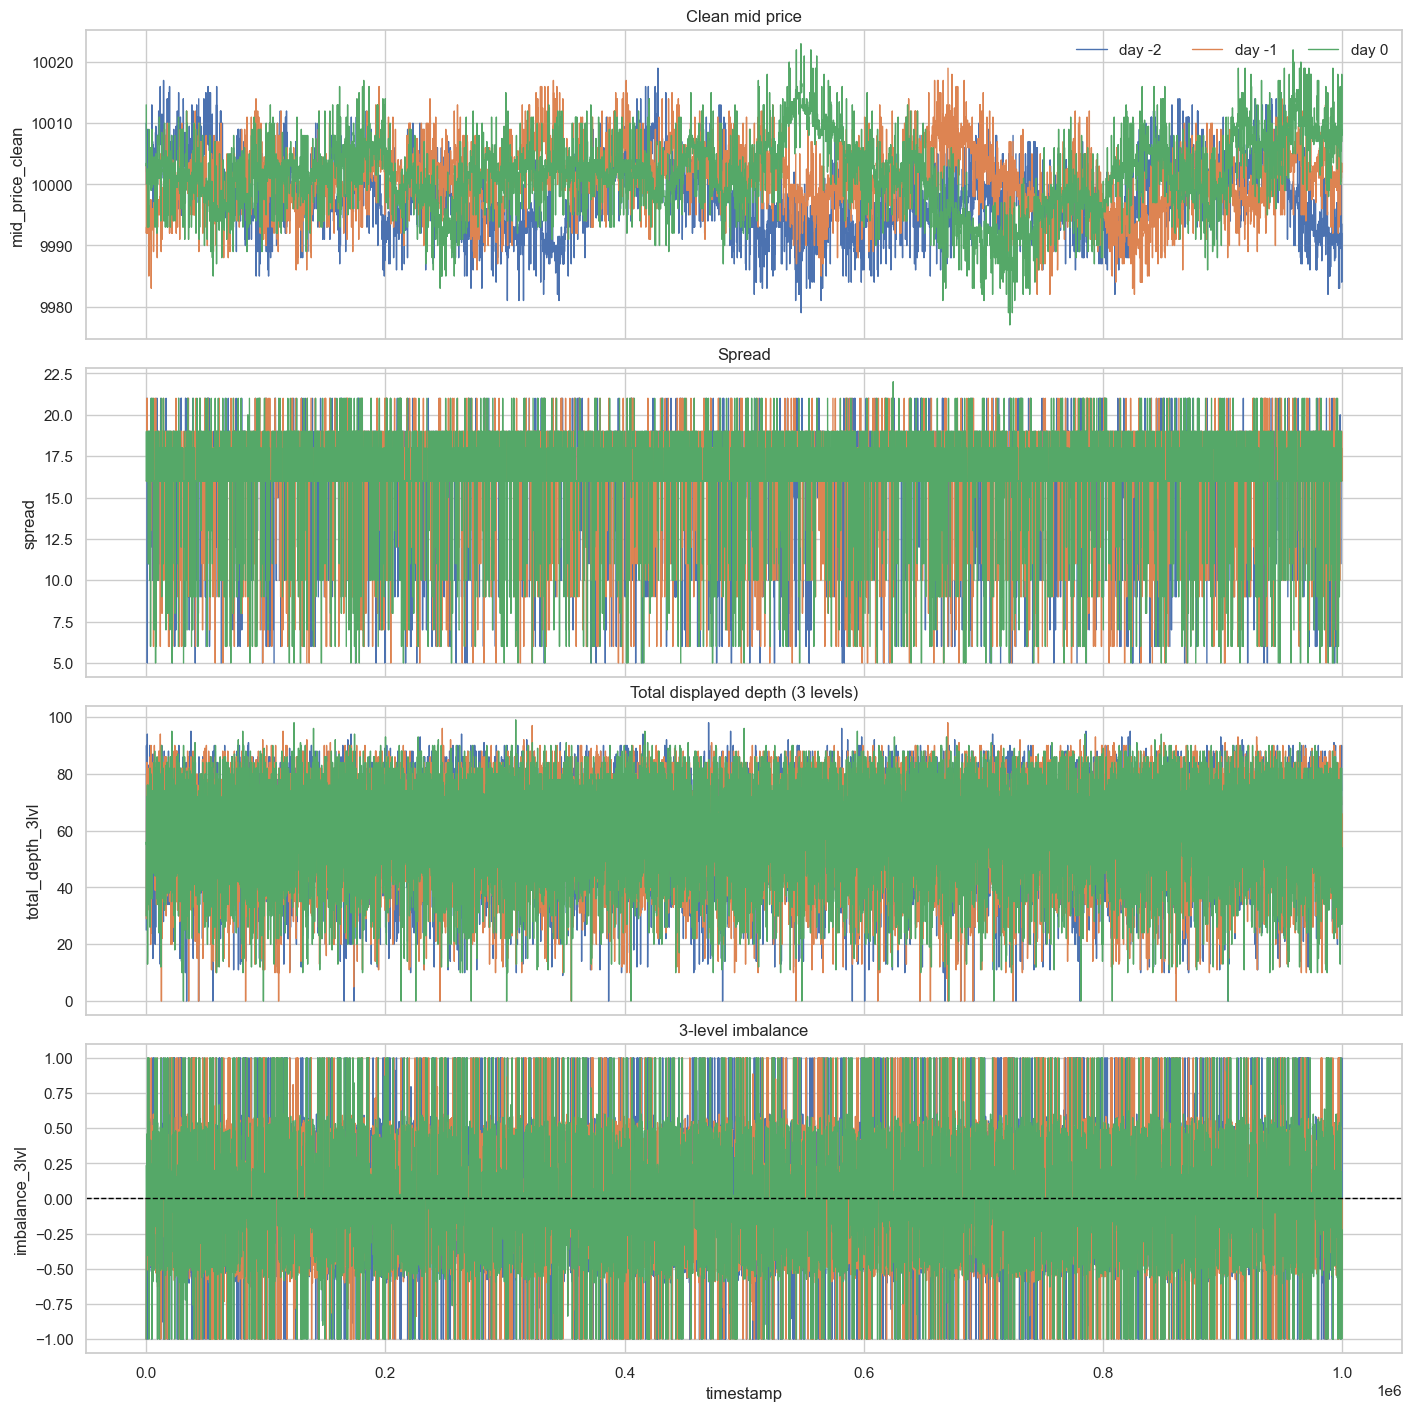

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True, constrained_layout=True)
metric_map = {
    "mid_price_clean": "Clean mid price",
    "spread": "Spread",
    "total_depth_3lvl": "Total displayed depth (3 levels)",
    "imbalance_3lvl": "3-level imbalance",
}

for axis, (column, title) in zip(axes, metric_map.items()):
    for day, day_frame in ash.groupby("day"):
        axis.plot(day_frame["timestamp"], day_frame[column], label=f"day {day}", linewidth=1)
    axis.set_title(title)
    axis.set_ylabel(column)
    if column == "imbalance_3lvl":
        axis.axhline(0, color="black", linestyle="--", linewidth=1)
axes[-1].set_xlabel("timestamp")
axes[0].legend(ncol=3, loc="upper right")
plt.show()


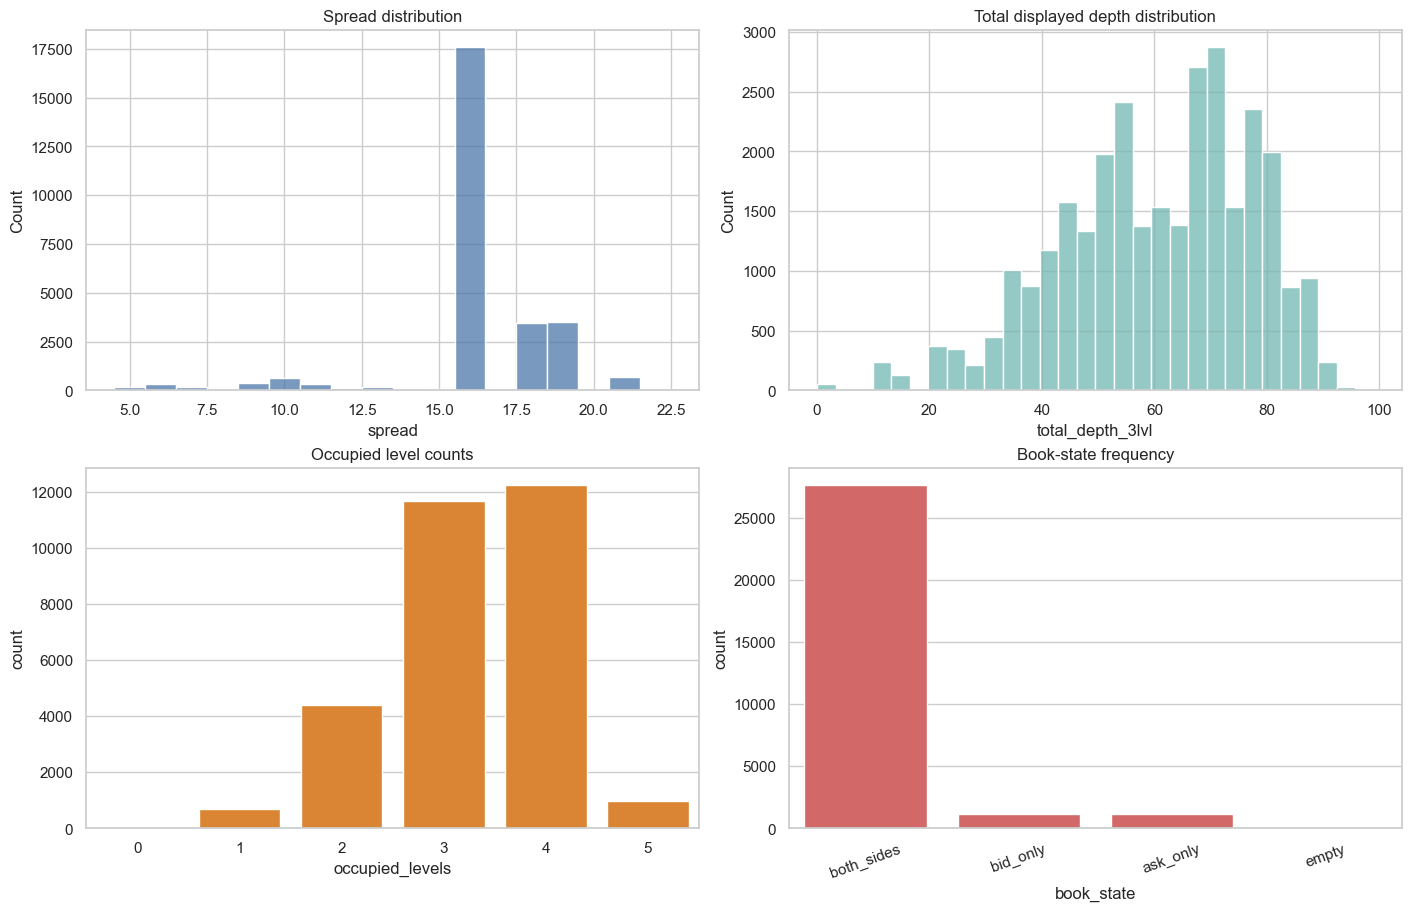

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

sns.histplot(ash["spread"].dropna(), discrete=True, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Spread distribution")

sns.histplot(ash["total_depth_3lvl"], bins=30, ax=axes[0, 1], color="#72B7B2")
axes[0, 1].set_title("Total displayed depth distribution")

sns.countplot(data=ash, x="occupied_levels", ax=axes[1, 0], color="#F58518")
axes[1, 0].set_title("Occupied level counts")

state_order = ["both_sides", "bid_only", "ask_only", "empty"]
sns.countplot(data=ash, x="book_state", order=state_order, ax=axes[1, 1], color="#E45756")
axes[1, 1].set_title("Book-state frequency")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.show()


**Interpretation.** ASH is a stable, tightly bounded book-driven product. It sits on both sides about 92% of the time, its typical spread is 16 ticks, and it carries roughly 60 units of visible depth across the first 3 levels. The cleaned mid stays in a narrow band around ~10,000 rather than trending through large regimes, which already points toward fair-value reversion and queue management being more plausible than pure momentum. One-sided books are rare, but they are not harmless: they behave like a distinct state and deserve special handling rather than being folded into the normal regime.


## 4. Price dynamics

The next question is whether ASH behaves like a drifting series, a stationary series, or a microstructure process dominated by bid/ask bounce. The emphasis here is on jump sizes, run lengths, autocorrelation, mean reversion, and whether spread/depth shocks add predictive information on top of the book state itself.


In [11]:
ash_acf = pd.DataFrame(
    {
        "lag": list(range(1, 21)),
        "autocorr": [ash["lagged_return_1"].dropna().autocorr(lag=lag) for lag in range(1, 21)],
    }
)

run_lengths = compute_run_lengths(ash["lagged_return_1"])
run_length_summary = run_lengths.describe(percentiles=[0.50, 0.75, 0.90, 0.99]).to_frame(name="run_length")

anchor = float(ash["mid_price_clean"].median())
ash_anchor = ash.copy()
ash_anchor["distance_from_anchor"] = ash_anchor["mid_price_clean"] - anchor
anchor_rows = []
for threshold in (2, 4, 6, 8, 10):
    anchor_rows.append(conditional_forward_stats(ash_anchor, ash_anchor["distance_from_anchor"] <= -threshold, f"{threshold}+ below anchor"))
    anchor_rows.append(conditional_forward_stats(ash_anchor, ash_anchor["distance_from_anchor"] >= threshold, f"{threshold}+ above anchor"))
anchor_reversion = pd.DataFrame(anchor_rows)

ash_state_effects = pd.DataFrame(
    [
        conditional_forward_stats(ash, ash["imbalance_3lvl"] >= ash["imbalance_3lvl"].quantile(0.90), "3-level imbalance top decile"),
        conditional_forward_stats(ash, ash["imbalance_3lvl"] <= ash["imbalance_3lvl"].quantile(0.10), "3-level imbalance bottom decile"),
        conditional_forward_stats(ash, ash["spread"] >= ash["spread"].quantile(0.90), "wide spread top decile"),
        conditional_forward_stats(ash, ash["spread"] <= ash["spread"].quantile(0.10), "narrow spread bottom decile"),
        conditional_forward_stats(ash, ash["total_depth_3lvl"] <= ash["total_depth_3lvl"].quantile(0.10), "thin depth bottom decile"),
        conditional_forward_stats(ash, ash["total_depth_3lvl"] >= ash["total_depth_3lvl"].quantile(0.90), "thick depth top decile"),
        conditional_forward_stats(ash, ash["spread_change"] >= ash["spread_change"].quantile(0.90), "spread widening shock"),
        conditional_forward_stats(ash, ash["spread_change"] <= ash["spread_change"].quantile(0.10), "spread narrowing shock"),
        conditional_forward_stats(ash, ash["depth_change"] >= ash["depth_change"].quantile(0.90), "positive depth shock"),
        conditional_forward_stats(ash, ash["depth_change"] <= ash["depth_change"].quantile(0.10), "negative depth shock"),
    ]
)

print(f"Reference anchor (median cleaned mid): {anchor:,.1f}")
print("Return autocorrelation")
display(ash_acf)
print("Signed run-length summary")
display(run_length_summary)
print("Anchor reversion table")
display(anchor_reversion)
print("Conditional forward-return table")
display(ash_state_effects)


Reference anchor (median cleaned mid): 10,000.5
Return autocorrelation


,lag,autocorr
0,1,-0.494
1,2,0.000
2,3,-0.001
3,4,0.001
4,5,-0.002
5,6,-0.000
6,7,0.003
7,8,-0.001
8,9,0.002
9,10,-0.008


Signed run-length summary


,run_length
count,"15,075.000"
mean,1.427
std,0.658
min,1.000
50%,1.000
75%,2.000
90%,2.000
99%,3.260
max,6.000


Anchor reversion table


,label,count,share,mean_1,up_rate_1,down_rate_1,mean_5,up_rate_5,down_rate_5,mean_10,up_rate_10,down_rate_10,mean_20,up_rate_20,down_rate_20
0,2+ below anchor,10984,0.366,1.113,0.469,0.268,1.119,0.503,0.304,1.170,0.528,0.320,1.249,0.549,0.328
1,2+ above anchor,9938,0.331,-1.235,0.252,0.487,-1.289,0.287,0.529,-1.350,0.299,0.555,-1.413,0.297,0.584
2,4+ below anchor,7195,0.240,1.501,0.509,0.249,1.536,0.544,0.279,1.630,0.575,0.290,1.683,0.592,0.296
3,4+ above anchor,5965,0.199,-1.739,0.232,0.533,-1.830,0.261,0.575,-1.916,0.271,0.596,-1.973,0.267,0.623
4,6+ below anchor,4402,0.147,1.988,0.546,0.223,2.060,0.583,0.252,2.091,0.605,0.267,2.220,0.626,0.269
5,6+ above anchor,3382,0.113,-2.402,0.203,0.585,-2.424,0.226,0.616,-2.498,0.239,0.641,-2.629,0.232,0.666
6,8+ below anchor,2432,0.081,2.539,0.596,0.199,2.640,0.631,0.222,2.779,0.664,0.223,2.891,0.677,0.227
7,8+ above anchor,1791,0.060,-3.385,0.160,0.661,-3.445,0.188,0.691,-3.476,0.196,0.707,-3.582,0.184,0.722
8,10+ below anchor,1197,0.040,3.648,0.702,0.150,3.967,0.741,0.152,4.081,0.770,0.151,4.330,0.794,0.136
9,10+ above anchor,892,0.030,-4.318,0.122,0.707,-4.300,0.155,0.729,-4.214,0.190,0.740,-4.402,0.167,0.749


Conditional forward-return table


,label,count,share,mean_1,up_rate_1,down_rate_1,mean_5,up_rate_5,down_rate_5,mean_10,up_rate_10,down_rate_10,mean_20,up_rate_20,down_rate_20
0,3-level imbalance top decile,3010,0.100,2.983,0.545,0.203,3.011,0.583,0.242,3.040,0.611,0.253,2.989,0.622,0.273
1,3-level imbalance bottom decile,3016,0.101,-3.000,0.200,0.536,-3.013,0.246,0.576,-2.976,0.268,0.593,-2.942,0.274,0.610
2,wide spread top decile,4185,0.140,0.053,0.482,0.463,-0.027,0.485,0.479,0.009,0.490,0.480,-0.110,0.468,0.506
3,narrow spread bottom decile,19973,0.666,0.015,0.303,0.301,0.018,0.365,0.364,-0.011,0.396,0.394,0.030,0.417,0.416
4,thin depth bottom decile,3096,0.103,-0.136,0.427,0.446,-0.150,0.436,0.463,-0.128,0.458,0.464,-0.117,0.456,0.477
5,thick depth top decile,3019,0.101,0.045,0.311,0.310,0.030,0.359,0.375,-0.044,0.381,0.405,0.009,0.404,0.435
6,spread widening shock,4544,0.151,0.006,0.412,0.416,-0.089,0.434,0.445,0.066,0.460,0.446,-0.049,0.447,0.469
7,spread narrowing shock,4529,0.151,0.033,0.376,0.385,0.074,0.411,0.416,0.060,0.434,0.434,0.041,0.437,0.458
8,positive depth shock,3175,0.106,-0.004,0.334,0.326,-0.050,0.382,0.384,-0.054,0.399,0.414,-0.015,0.429,0.423
9,negative depth shock,3121,0.104,0.037,0.408,0.408,0.014,0.430,0.435,0.015,0.446,0.453,-0.079,0.442,0.468


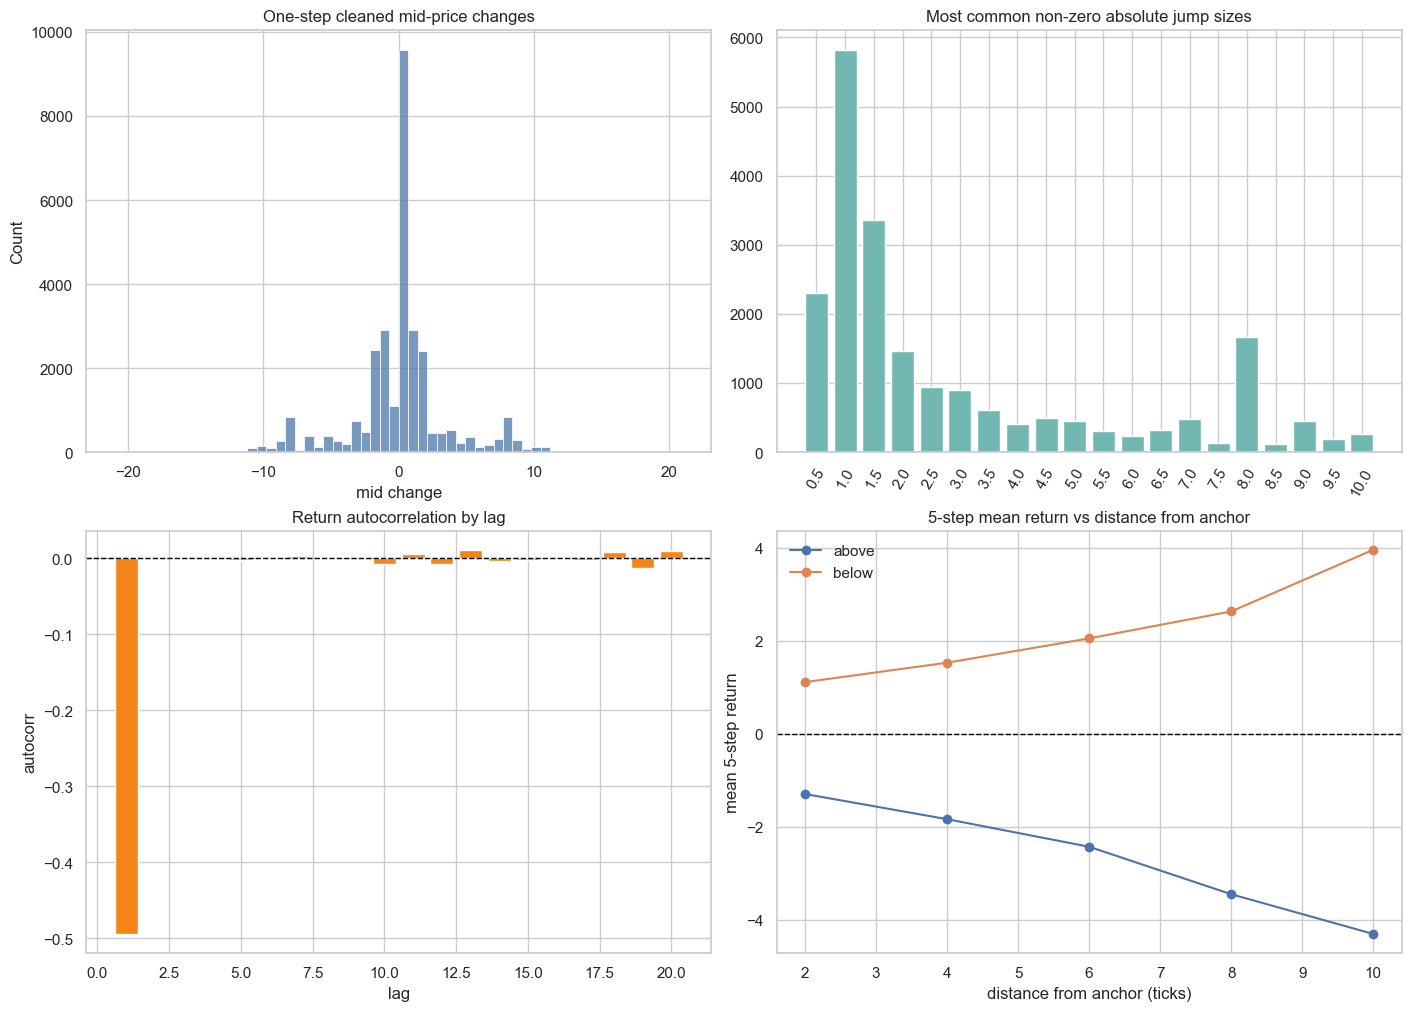

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

sns.histplot(ash["lagged_return_1"].dropna(), bins=60, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("One-step cleaned mid-price changes")
axes[0, 0].set_xlabel("mid change")

abs_change_counts = ash.loc[ash["abs_mid_change"] > 0, "abs_mid_change"].value_counts().sort_index().head(20)
axes[0, 1].bar(abs_change_counts.index.astype(str), abs_change_counts.values, color="#72B7B2")
axes[0, 1].set_title("Most common non-zero absolute jump sizes")
axes[0, 1].tick_params(axis="x", rotation=60)

axes[1, 0].bar(ash_acf["lag"], ash_acf["autocorr"], color="#F58518")
axes[1, 0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1, 0].set_title("Return autocorrelation by lag")
axes[1, 0].set_xlabel("lag")
axes[1, 0].set_ylabel("autocorr")

anchor_plot = anchor_reversion.assign(threshold=anchor_reversion["label"].str.extract(r"(\d+)", expand=False).astype(int), side=np.where(anchor_reversion["label"].str.contains("below"), "below", "above"))
for side, side_frame in anchor_plot.groupby("side"):
    axes[1, 1].plot(side_frame["threshold"], side_frame["mean_5"], marker="o", label=side)
axes[1, 1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title("5-step mean return vs distance from anchor")
axes[1, 1].set_xlabel("distance from anchor (ticks)")
axes[1, 1].set_ylabel("mean 5-step return")
axes[1, 1].legend()

plt.show()


**Interpretation.** ASH behaves like a strong short-horizon mean-reversion process. The lag-1 return autocorrelation is sharply negative, most signed runs last only 1 to 2 updates, and excursions away from the ~10,000 anchor tend to mean-revert over the next few timestamps. Book imbalance extremes carry real directional information, while pure spread changes and depth shocks are much weaker on their own. In other words, the signal is not “spread widens, therefore move”; it is “the book becomes meaningfully one-sided or the price lurches, then ASH tends to snap back unless the book pressure is still extreme.”


## 5. Liquidity and execution implications

A viable strategy depends on what can be traded without giving away the edge in slippage. This section summarizes displayed size by level, how the trade tape interacts with the book, and how quickly aggressive orders would walk the visible ask/bid stack.


In [13]:
ash_trade_frame = trades.query("symbol == @TARGET_PRODUCT")
ash_trade_summary = pd.Series(
    {
        "trades": ash_trade_frame["timestamp"].size,
        "unique_trade_timestamps": ash_trade_frame["timestamp"].nunique(),
        "mean_trade_qty": ash_trade_frame["quantity"].mean(),
        "median_trade_qty": ash_trade_frame["quantity"].median(),
        "max_trade_qty": ash_trade_frame["quantity"].max(),
        "at_bid_share": ash_trade_frame["at_bid"].mean(),
        "at_ask_share": ash_trade_frame["at_ask"].mean(),
        "at_mid_share": ash_trade_frame["at_mid"].mean(),
        "inside_spread_share": ash_trade_frame["inside_spread"].mean(),
        "outside_touch_share": ash_trade_frame["outside_touch"].mean(),
    },
    name="ASH trades",
).to_frame()
ash_trade_summary.loc["share_of_quote_grid", "ASH trades"] = ash_trade_summary.loc["unique_trade_timestamps", "ASH trades"] / len(ash)

ash_level_volumes = pd.DataFrame(
    {
        "bid_level_1": ash["bid_volume_1"].describe(),
        "bid_level_2": ash["bid_volume_2"].describe(),
        "bid_level_3": ash["bid_volume_3"].describe(),
        "ask_level_1": ash["ask_volume_1"].describe(),
        "ask_level_2": ash["ask_volume_2"].describe(),
        "ask_level_3": ash["ask_volume_3"].describe(),
    }
)

cumulative_depth = pd.DataFrame(
    {
        "level": [1, 2, 3],
        "mean_cumulative_bid_depth": [ash[[f"bid_volume_{lvl}" for lvl in range(1, level + 1)]].fillna(0).sum(axis=1).mean() for level in (1, 2, 3)],
        "mean_cumulative_ask_depth": [ash[[f"ask_volume_{lvl}" for lvl in range(1, level + 1)]].fillna(0).sum(axis=1).mean() for level in (1, 2, 3)],
    }
)

order_sizes = [5, 10, 20, 30, 40, 50, 60, 80]
buy_costs = estimate_visible_execution_cost(ash, sizes=order_sizes, side="buy")
sell_costs = estimate_visible_execution_cost(ash, sizes=order_sizes, side="sell")
execution_costs = pd.concat([buy_costs, sell_costs], ignore_index=True)

print("Trade summary")
display(ash_trade_summary)
print("Visible level-volume summary")
display(ash_level_volumes)
print("Mean cumulative visible depth")
display(cumulative_depth)
print("Visible execution cost summary")
display(execution_costs)


Trade summary


,ASH trades
trades,"1,265.000"
unique_trade_timestamps,"1,200.000"
mean_trade_qty,5.212
median_trade_qty,5.000
max_trade_qty,10.000
at_bid_share,0.489
at_ask_share,0.511
at_mid_share,0.028
inside_spread_share,0.000
outside_touch_share,0.000


Visible level-volume summary


,bid_level_1,bid_level_2,bid_level_3,ask_level_1,ask_level_2,ask_level_3
count,"28,796.000","19,596.000",779.000,"28,799.000","19,552.000",747.000
mean,14.122,24.350,24.929,14.164,24.463,24.936
std,5.348,4.170,3.370,5.322,4.094,3.259
min,2.000,2.000,11.000,1.000,2.000,12.000
25%,11.000,22.000,22.000,11.000,22.000,22.000
50%,13.000,25.000,25.000,13.000,25.000,25.000
75%,15.000,28.000,28.000,15.000,28.000,28.000
max,30.000,30.000,30.000,30.000,30.000,30.000


Mean cumulative visible depth


,level,mean_cumulative_bid_depth,mean_cumulative_ask_depth
0,1,13.555,13.597
1,2,29.460,29.540
2,3,30.107,30.161


Visible execution cost summary


,side,size,avg_fill_share,full_fill_share,mean_slippage,p90_slippage
0,buy,5,1.000,0.999,0.059,0.000
1,buy,10,0.999,0.998,0.161,0.000
2,buy,20,0.938,0.833,0.850,1.350
3,buy,30,0.875,0.684,1.224,1.900
4,buy,40,0.775,0.223,1.368,2.100
5,buy,50,0.628,0.001,1.379,2.118
6,buy,60,0.524,0.000,1.379,2.118
7,buy,80,0.393,0.000,1.379,2.118
8,sell,5,0.999,0.999,0.054,0.000
9,sell,10,0.999,0.998,0.143,0.000


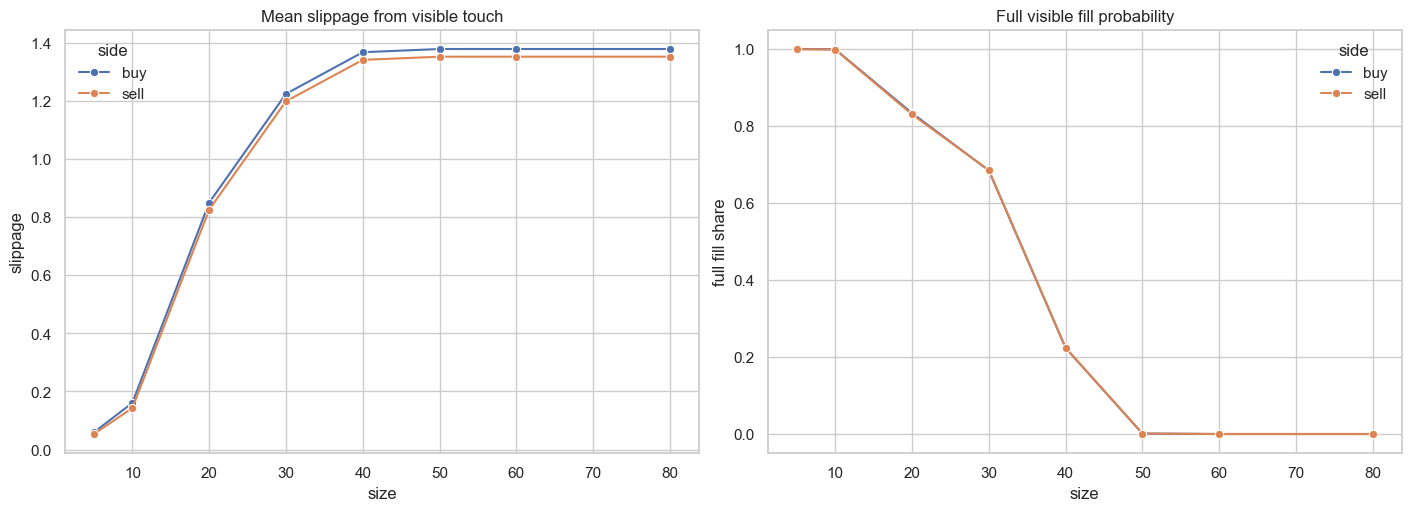

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.lineplot(data=execution_costs, x="size", y="mean_slippage", hue="side", marker="o", ax=axes[0])
axes[0].set_title("Mean slippage from visible touch")
axes[0].set_ylabel("slippage")

sns.lineplot(data=execution_costs, x="size", y="full_fill_share", hue="side", marker="o", ax=axes[1])
axes[1].set_title("Full visible fill probability")
axes[1].set_ylabel("full fill share")

plt.show()


**Interpretation.** ASH is tradable, but not infinitely forgiving. Small orders fit comfortably inside the best quote most of the time, while larger aggressive sizes quickly start walking the book and losing fill probability. The trade tape is sparse relative to the quote grid and prints almost entirely at the bid or ask, which is exactly the environment where queue position, passive fills, and inventory-aware quoting matter more than brute-force taking. That makes ASH look better suited to controlled market making or selective taker logic than to large uninformed sweeps.


## 6. Cross-product comparison and lead-lag checks

`INTARIAN_PEPPER_ROOT` is not ASH’s sibling in any obvious sense, but it is useful as a benchmark. If both products shared the same timing structure, a lot of apparent ASH signal could just be a round-wide regime effect. If they do not, ASH is likely a self-contained microstructure problem.


In [15]:
product_comparison = []
for product, frame in quotes.groupby("product"):
    product_trades = trades.query("symbol == @product")
    product_comparison.append(
        {
            "product": product,
            "clean_mid_mean": frame["mid_price_clean"].mean(),
            "clean_mid_std": frame["mid_price_clean"].std(),
            "intraday_return_std": frame["lagged_return_1"].dropna().std(),
            "spread_mean": frame["spread"].mean(),
            "spread_median": frame["spread"].median(),
            "top_depth_mean": frame["top_depth"].mean(),
            "total_depth_mean": frame["total_depth_3lvl"].mean(),
            "both_sides_share": frame["both_sides"].mean(),
            "empty_share": frame["book_empty"].mean(),
            "price_update_share": (frame["lagged_return_1"].fillna(0) != 0).mean(),
            "quote_update_share": frame["quote_update"].mean(),
            "trade_timestamp_share": product_trades["timestamp"].nunique() / len(frame),
        }
    )
product_comparison = pd.DataFrame(product_comparison)

lead_lag = lead_lag_correlation(ash, ipr, max_lag=20)
predictive_lag_table = predictive_driver_correlations(ash, ipr)

intraday_bucket_summary = (
    quotes.assign(time_bucket=pd.cut(quotes["timestamp"], bins=np.linspace(0, 1_000_000, 11), include_lowest=True))
    .groupby(["product", "time_bucket"], observed=False)
    .agg(mean_mid=("mid_price_clean", "mean"), mean_spread=("spread", "mean"))
    .reset_index()
)

print("Product comparison")
display(product_comparison)
print("Lead/lag correlation of ASH returns vs lagged IPR returns (positive lag means IPR moved earlier)")
display(lead_lag)
print("Predictive correlations from lagged IPR returns into future ASH returns")
display(predictive_lag_table)


Product comparison


,product,clean_mid_mean,clean_mid_std,intraday_return_std,spread_mean,spread_median,top_depth_mean,total_depth_mean,both_sides_share,empty_share,price_update_share,quote_update_share,trade_timestamp_share
0,ASH_COATED_OSMIUM,"10,000.204",5.350,3.723,16.175,16.000,27.152,60.268,0.921,0.002,0.717,0.955,0.040
1,INTARIAN_PEPPER_ROOT,"11,499.889",866.107,3.100,13.047,13.000,22.157,48.369,0.923,0.002,0.656,0.942,0.032


Lead/lag correlation of ASH returns vs lagged IPR returns (positive lag means IPR moved earlier)


,lag,corr
0,-20,-0.002
1,-19,-0.003
2,-18,0.001
3,-17,0.002
4,-16,-0.005
5,-15,0.010
6,-14,-0.016
7,-13,0.013
8,-12,-0.003
9,-11,0.000


Predictive correlations from lagged IPR returns into future ASH returns


,driver_lead_lag,corr_with_ash_fwd5,corr_with_ash_fwd10
0,0,-0.010,-0.007
1,1,0.008,0.008
2,2,0.003,0.006
3,5,0.003,0.004
4,10,0.002,0.004


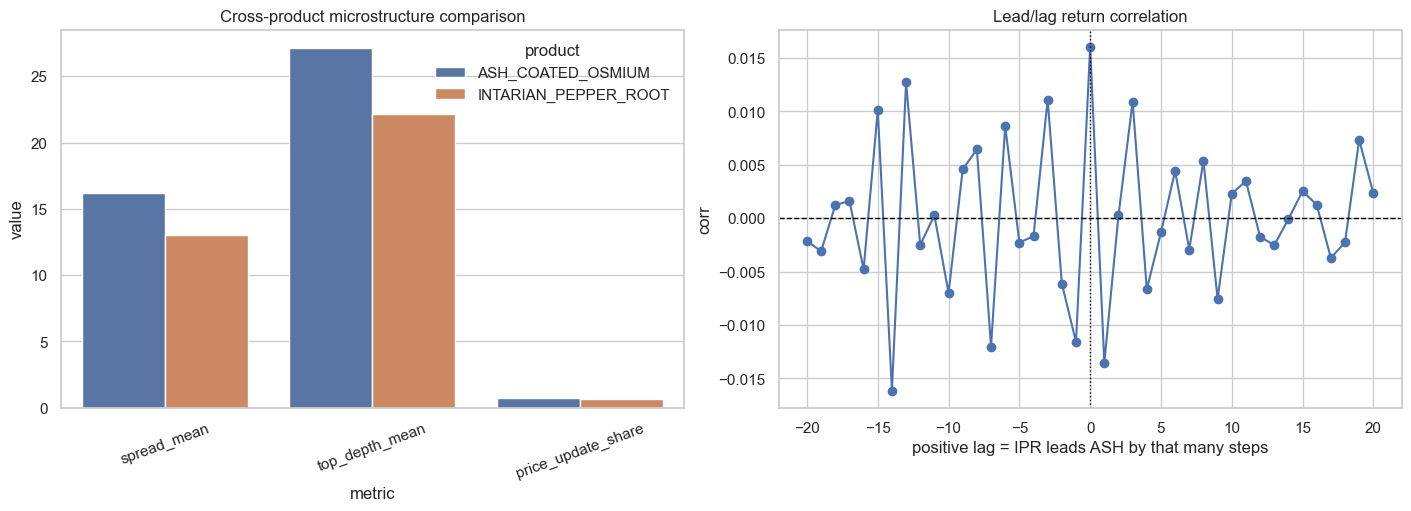

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

comparison_plot = product_comparison.melt(id_vars="product", value_vars=["spread_mean", "top_depth_mean", "price_update_share"], var_name="metric", value_name="value")
sns.barplot(data=comparison_plot, x="metric", y="value", hue="product", ax=axes[0])
axes[0].set_title("Cross-product microstructure comparison")
axes[0].tick_params(axis="x", rotation=20)

axes[1].plot(lead_lag["lag"], lead_lag["corr"], marker="o")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].axvline(0, color="black", linestyle=":", linewidth=1)
axes[1].set_title("Lead/lag return correlation")
axes[1].set_xlabel("positive lag = IPR leads ASH by that many steps")
axes[1].set_ylabel("corr")

plt.show()


**Interpretation.** The comparison is informative even though the lead-lag result is not. ASH is deeper, a bit wider, and more anchored than IPR, while IPR sweeps through a much stronger cross-day and intraday trend. That contrast makes ASH look like a stationary book problem rather than a shared macro regime. The lag correlations between IPR and ASH are effectively zero across short horizons, so there is no evidence here that IPR should be treated as a useful lead signal for ASH.


## 7. Potential predictive features

This section turns the EDA into a signal checklist. For each candidate feature, the notebook defines the feature, looks at its distribution, tests its relationship with short-horizon forward returns, and scores whether it looks promising, secondary, or weak/noisy.


In [17]:
feature_definition_table = pd.DataFrame(FEATURE_SPECS)
feature_scorecard = build_feature_scorecard(ash, FEATURE_SPECS)
interaction_scorecard = build_alignment_signal_table(ash)

print("Feature definitions")
display(feature_definition_table)
print("Feature scorecard")
display(feature_scorecard)
print("Interaction of the two strongest short-horizon signals")
display(interaction_scorecard)


Feature definitions


,name,column,definition
0,3-level order book imbalance,imbalance_3lvl,(3-level bid depth - 3-level ask depth) / tota...
1,Top-of-book imbalance,imbalance_top,(best-bid size - best-ask size) / top-of-book ...
2,Spread,spread,Best ask minus best bid in price ticks.
3,Relative spread (bps),relative_spread_bps,"Spread divided by cleaned mid price, expressed..."
4,Total displayed depth,total_depth_3lvl,Visible bid plus ask volume across the first 3...
5,Top-depth ratio,top_depth_ratio,Best-bid size divided by best-ask size when bo...
6,Occupied levels,occupied_levels,Number of populated bid/ask price levels out o...
7,Recent 5-step momentum,momentum_5,Rolling 5-step sum of cleaned mid-price change...
8,Quote update intensity (20-step),quote_update_intensity_20,Rolling count of top-of-book quote updates ove...
9,Lagged return,lagged_return_1,The last cleaned mid-price change (one timesta...


Feature scorecard


,feature,column,corr_fwd5,corr_fwd10,bottom_decile_fwd5,top_decile_fwd5,direction_gap_fwd5,day_consistency,assessment
0,Top-of-book imbalance,imbalance_top,0.640,0.627,-4.498,4.547,0.818,3/3,promising
1,Lagged return,lagged_return_1,-0.490,-0.485,3.677,-3.744,-0.507,3/3,promising
2,Recent 5-step momentum,momentum_5,-0.477,-0.472,3.652,-3.520,-0.495,3/3,promising
3,3-level order book imbalance,imbalance_3lvl,0.401,0.396,-3.013,3.013,0.337,3/3,promising
4,Top-depth ratio,top_depth_ratio,0.367,0.362,-4.632,2.039,0.753,3/3,promising
5,Spread,spread,-0.036,-0.027,0.017,-0.029,0.120,3/3,weak/noisy
6,Relative spread (bps),relative_spread_bps,-0.036,-0.026,0.086,0.218,0.085,2/3,weak/noisy
7,Occupied levels,occupied_levels,0.016,0.006,-0.042,0.034,-0.090,3/3,weak/noisy
8,Total displayed depth,total_depth_3lvl,0.009,0.004,-0.150,0.032,-0.077,3/3,weak/noisy
9,Quote update intensity (20-step),quote_update_intensity_20,0.005,0.004,0.016,-0.002,0.004,2/3,weak/noisy


Interaction of the two strongest short-horizon signals


,label,count,share,mean_5,up_rate_5,down_rate_5,mean_10,up_rate_10,down_rate_10
0,buy_aligned (positive top imbalance + recent d...,1519,0.051,6.829,0.938,0.041,6.999,0.958,0.028
1,sell_aligned (negative top imbalance + recent ...,1444,0.048,-7.165,0.024,0.958,-7.133,0.030,0.953
2,conflict_positive (positive imbalance + recent...,72,0.002,2.347,0.861,0.069,2.507,0.833,0.083
3,conflict_negative (negative imbalance + recent...,93,0.003,-1.919,0.108,0.860,-2.005,0.185,0.783


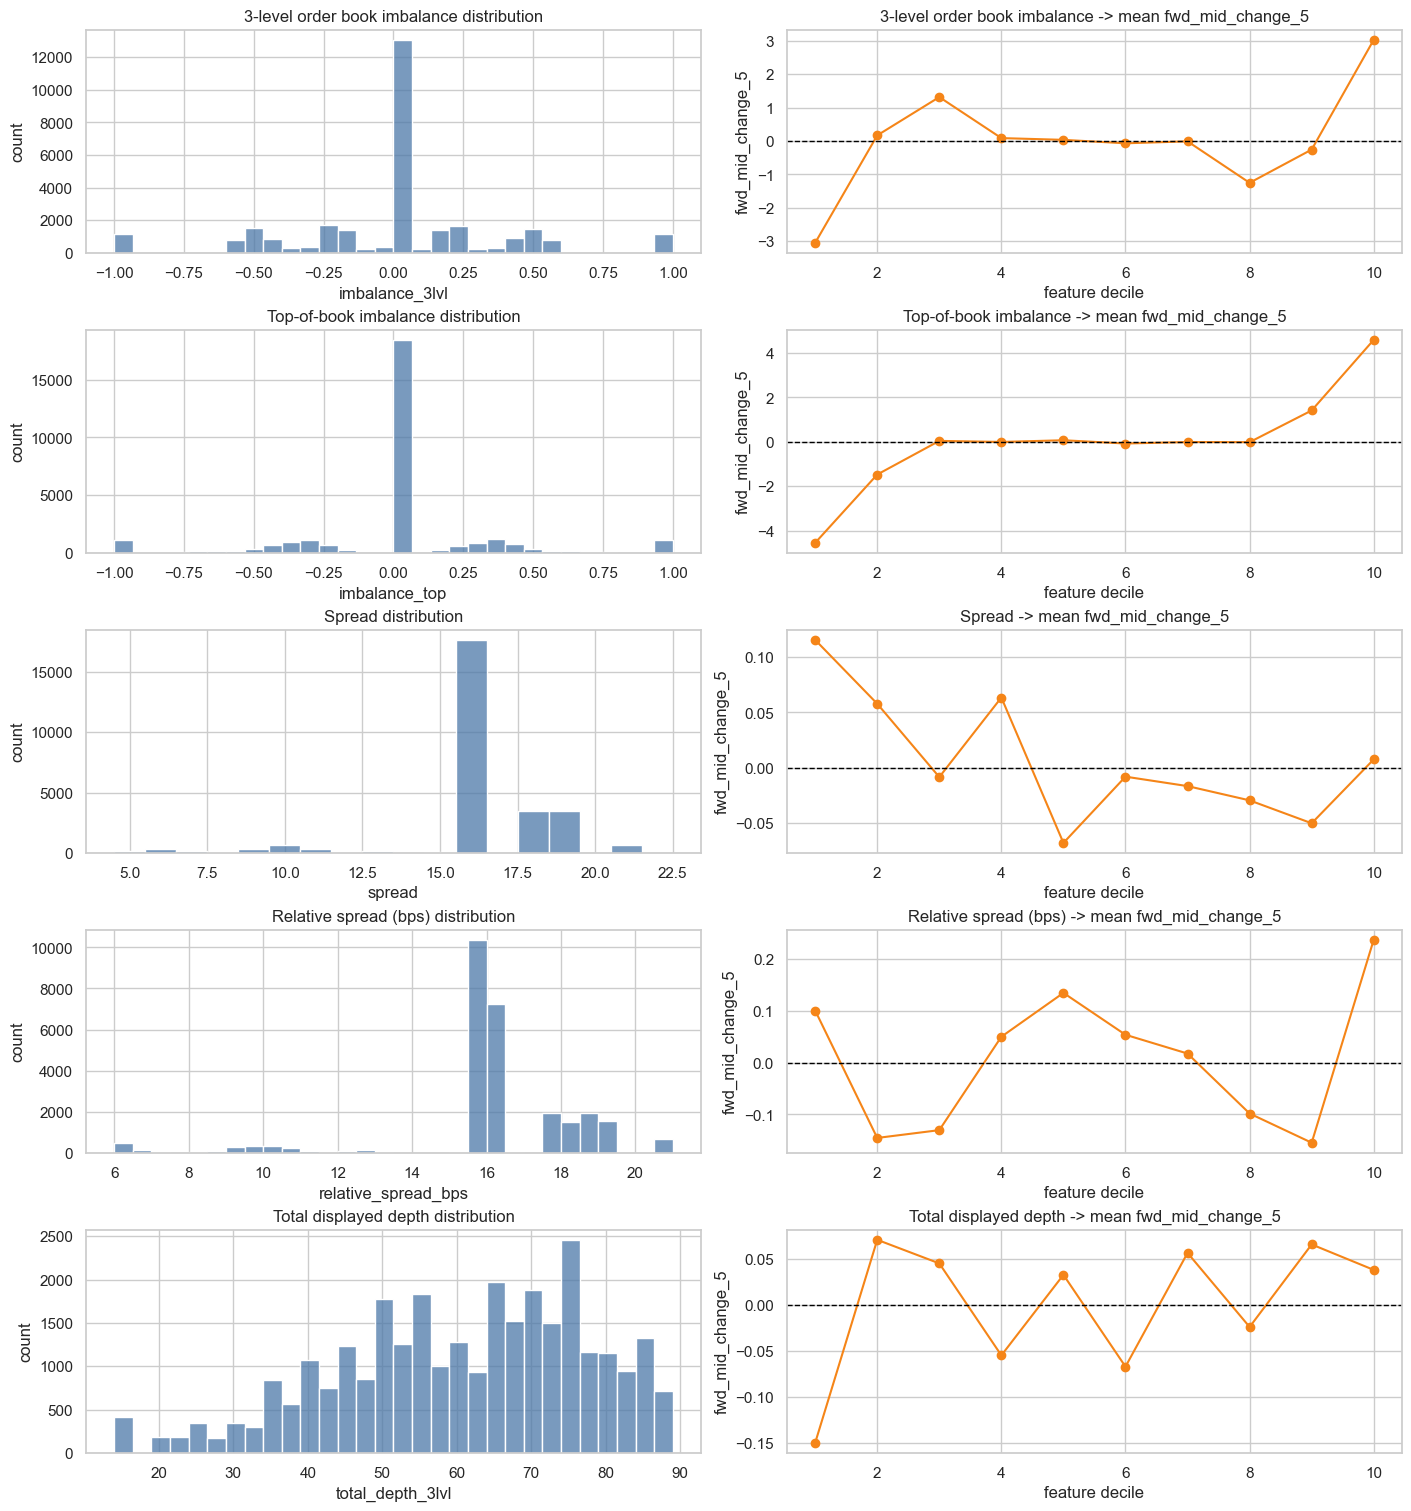

In [18]:
plot_feature_panels(ash, FEATURE_SPECS[:5], target_col="fwd_mid_change_5")


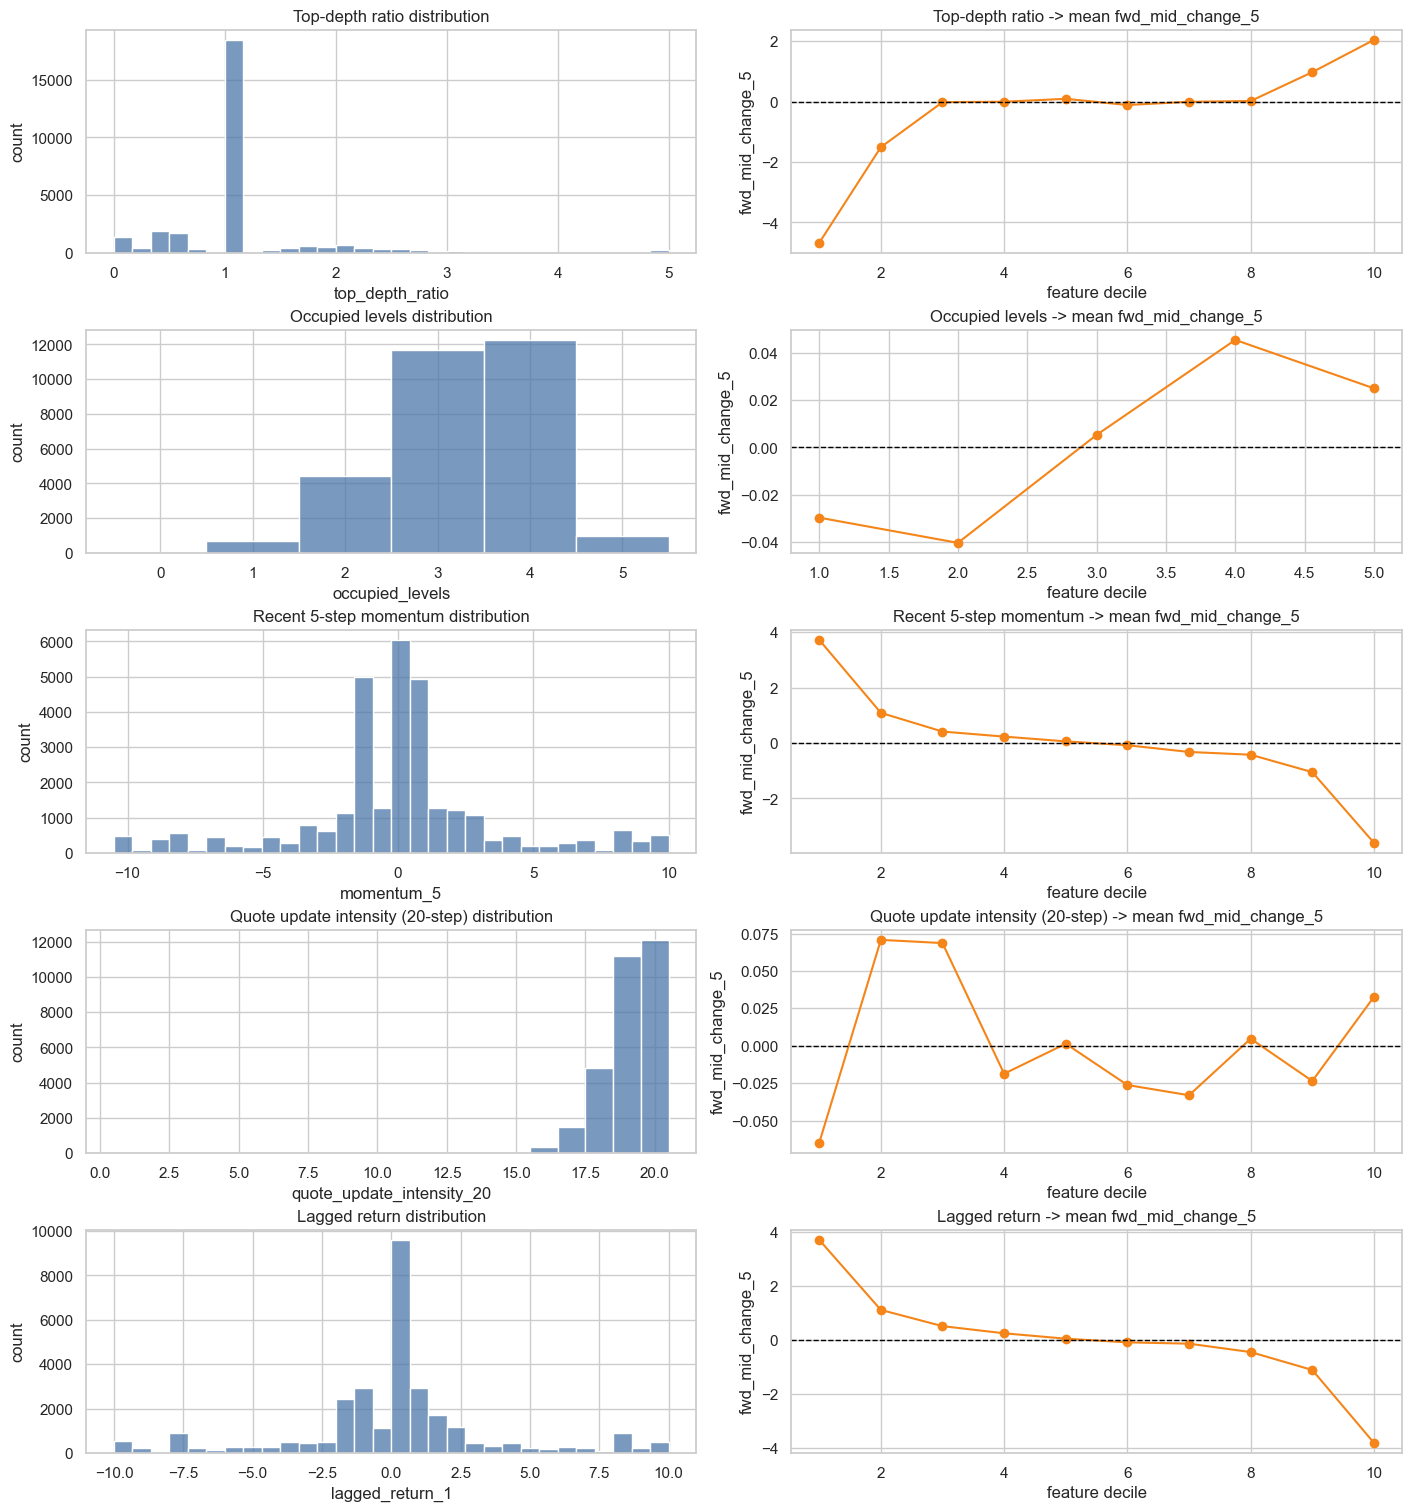

In [19]:
plot_feature_panels(ash, FEATURE_SPECS[5:], target_col="fwd_mid_change_5")


**Interpretation.** The standout features are top-of-book imbalance, 3-level imbalance, lagged return, and short-horizon momentum/reversal. They are not only strong in sample; they are directionally consistent across all three days. Spread, relative spread, total depth, occupied levels, and quote update intensity are much weaker on their own. The feature interaction table sharpens the picture further: when top-book imbalance and short-term reversion point the same way, the forward move is materially stronger than either signal alone. That is exactly the kind of structure worth carrying into a baseline strategy.


## 8. What this suggests for algorithm design

- **Main behavioral properties.** `ASH_COATED_OSMIUM` looks like a stable, depth-supported product anchored around a narrow fair-value region near 10,000. It updates frequently, but the price path is dominated by short-horizon reversion rather than sustained continuation.
- **Most plausible edge.** The clearest edge is not raw momentum. It is microstructure-aware reversion: lean against short-lived dislocations, especially when recent price movement and visible book imbalance line up.
- **Best first strategy family.** A baseline market-making strategy with a rolling fair value, inventory limits, and quote skew from top-of-book / 3-level imbalance is the most natural starting point. Add selective taker rules only when the book is extremely asymmetric or when one-sided states appear and the execution model still looks realistic.
- **Important traps.** One-sided or empty books can distort naive mid-price calculations; depth-only signals are weak; spread widening/narrowing by itself is not a strong directional cue; and the apparent signal strength will be overstated if backtests assume frictionless fills.
- **Signals worth carrying forward.** Top imbalance, 3-level imbalance, lagged return, 5-step momentum/reversal, anchor distance, book-state flags, and interaction terms between imbalance and recent return all deserve a place in the first modelling pass.
- **Practical modelling note.** Because the strongest effects are very short horizon and very microstructural, the backtest should be queue-aware or at least conservative about passive fills and taker slippage.


## 9. Final deliverables

**Most important findings**
- `ASH_COATED_OSMIUM` is a stationary-looking book around ~10,000, not a strong drift process like `INTARIAN_PEPPER_ROOT`.
- The raw quote files are clean, but `mid_price` must be cleaned when the book is empty, and `profit_and_loss` should be ignored.
- ASH is quoted on both sides about 92% of the time, with a typical 16-tick spread and roughly 60 units of visible 3-level depth.
- Short-horizon mean reversion is strong: lagged returns, anchor distance, and book imbalance all point toward snap-back behavior rather than continuation.
- Cross-product lead/lag from `INTARIAN_PEPPER_ROOT` into ASH is effectively absent.

**3 to 5 concrete strategy hypotheses to test next**
- Market make around a rolling fair value, skewing bid/ask quotes by top-of-book imbalance and current inventory.
- Add a taker overlay that only fires when top-book imbalance and recent reversal align in the same direction.
- Test an anchor-reversion strategy that becomes more aggressive when ASH is 6 to 10 ticks away from its rolling median or microprice anchor.
- Explicitly detect one-sided-book states and either widen/suspend quotes or treat them as a separate high-conviction regime.
- Compare pure top-of-book imbalance, 3-level imbalance, and their interaction with lagged return in a conservative fill model.

**Most useful engineered features to export**
- `imbalance_top`
- `imbalance_3lvl`
- `lagged_return_1`
- `momentum_5`
- `distance_from_anchor` (or an adaptive fair-value residual)
- `book_state` / one-sided flags
- `top_depth_ratio`
- interaction terms such as `imbalance_top * -lagged_return_1`


## 10. Strategy recap

This section keeps the original EDA intact and turns its conclusions into conservative round-1 strategy checks for `ASH_COATED_OSMIUM`.

The strategy work only carries forward signals that survived the EDA:
- ASH is anchored around ~10,000 and behaves like a short-horizon mean-reversion product.
- The useful signals are imbalance, short-horizon reversal, anchor distance, and explicit book-state handling.
- The backtests below use a strict execution model with delayed action, queue haircuts, taker penalties, and forced end-of-day flattening.

## 11. Strategy feature frame

The strategy dataframe is built separately from the original EDA dataframe. It reuses the same raw quotes and trades, but it tightens quote cleaning so the strategy logic never treats one-sided or empty-book raw `mid_price` values as fair value.

In [20]:
from IPython.display import Markdown, display

def rolling_median_with_fallback(series: pd.Series, window: int) -> pd.Series:
    rolling = series.rolling(window, min_periods=window).median()
    expanding = series.expanding(min_periods=1).median()
    return rolling.fillna(expanding)


def build_ash_strategy_frame(quotes: pd.DataFrame, trades: pd.DataFrame, target_product: str) -> pd.DataFrame:
    frame = quotes.copy()
    if "product" in frame.columns and frame["product"].nunique() > 1:
        frame = frame.query("product == @target_product").copy()
    trade_frame = trades.copy()
    if "symbol" in trade_frame.columns and trade_frame["symbol"].nunique() > 1:
        trade_frame = trade_frame.query("symbol == @target_product").copy()

    frame = frame.sort_values(["day", "timestamp"]).reset_index(drop=True)
    frame["touch_mid_only"] = np.where(frame["both_sides"], (frame["best_bid"] + frame["best_ask"]) / 2, np.nan)
    frame["clean_mid"] = frame.groupby("day")["touch_mid_only"].transform(lambda s: s.ffill())
    expanding_mid = frame.groupby("day")["touch_mid_only"].transform(lambda s: s.expanding(min_periods=1).median())
    frame["clean_mid"] = frame["clean_mid"].fillna(expanding_mid)

    frame["spread"] = frame["best_ask"] - frame["best_bid"]
    frame["lagged_return_1"] = frame.groupby("day")["clean_mid"].diff()
    frame["momentum_5"] = frame.groupby("day")["lagged_return_1"].transform(lambda s: s.rolling(5, min_periods=1).sum())
    frame["top_depth_ratio"] = np.where(frame["top_ask_depth"] > 0, frame["top_bid_depth"] / frame["top_ask_depth"], np.nan)
    frame["book_state_normal"] = (frame["book_state"] == "both_sides").astype(int)
    frame["book_state_bid_only"] = (frame["book_state"] == "bid_only").astype(int)
    frame["book_state_ask_only"] = (frame["book_state"] == "ask_only").astype(int)
    frame["book_state_empty"] = (frame["book_state"] == "empty").astype(int)

    for fair_window in (50, 100):
        frame[f"rolling_fair_{fair_window}"] = frame.groupby("day")["clean_mid"].transform(
            lambda s, w=fair_window: rolling_median_with_fallback(s, w)
        )
    for anchor_window in (200, 300):
        frame[f"rolling_anchor_{anchor_window}"] = frame.groupby("day")["clean_mid"].transform(
            lambda s, w=anchor_window: rolling_median_with_fallback(s, w)
        )
        frame[f"distance_from_anchor_{anchor_window}"] = frame["clean_mid"] - frame[f"rolling_anchor_{anchor_window}"]

    frame["distance_from_anchor"] = frame["distance_from_anchor_200"]
    frame["interaction_reversion_top"] = frame["imbalance_top"] * (-frame["lagged_return_1"])
    frame["interaction_reversion_3lvl"] = frame["imbalance_3lvl"] * (-frame["momentum_5"])

    trade_map = trade_frame.groupby(["day", "timestamp", "price"])["quantity"].sum().to_dict()

    def lookup_qty(day: int, timestamp: int, price: float) -> float:
        if pd.isna(price):
            return 0.0
        return float(trade_map.get((day, timestamp, float(price)), 0.0))

    bid_qty = []
    ask_qty = []
    for row in frame.itertuples(index=False):
        bid_qty.append(lookup_qty(int(row.day), int(row.timestamp), row.best_bid))
        ask_qty.append(lookup_qty(int(row.day), int(row.timestamp), row.best_ask))
    frame["trade_qty_at_bid"] = bid_qty
    frame["trade_qty_at_ask"] = ask_qty

    for column in ["best_bid", "best_ask", "clean_mid", "book_state"]:
        frame[f"next_{column}"] = frame.groupby("day")[column].shift(-1)
    frame["day_end"] = frame.groupby("day")["timestamp"].shift(-1).isna()
    return frame

ash_strategy = build_ash_strategy_frame(ash, trades, TARGET_PRODUCT)

strategy_feature_preview_cols = [
    'day',
    'timestamp',
    'book_state',
    'clean_mid',
    'rolling_fair_50',
    'rolling_anchor_200',
    'distance_from_anchor',
    'imbalance_top',
    'imbalance_3lvl',
    'lagged_return_1',
    'momentum_5',
    'interaction_reversion_top',
]
strategy_state_summary = (
    ash_strategy.groupby('book_state')
    .agg(
        rows=('timestamp', 'size'),
        share=('timestamp', lambda s: float(len(s) / len(ash_strategy))),
        mean_spread=('spread', 'mean'),
        mean_clean_mid=('clean_mid', 'mean'),
    )
    .reset_index()
)
strategy_feature_summary = pd.DataFrame(
    [
        {'metric': 'rows', 'value': int(len(ash_strategy))},
        {'metric': 'valid clean_mid share', 'value': float(ash_strategy['clean_mid'].notna().mean())},
        {'metric': 'both-sides share', 'value': float((ash_strategy['book_state'] == 'both_sides').mean())},
        {'metric': 'one-sided share', 'value': float(ash_strategy['book_state'].isin(['bid_only', 'ask_only']).mean())},
        {'metric': 'empty share', 'value': float((ash_strategy['book_state'] == 'empty').mean())},
        {'metric': 'median spread', 'value': float(ash_strategy['spread'].median())},
        {'metric': 'mean abs distance_from_anchor', 'value': float(ash_strategy['distance_from_anchor'].abs().mean())},
    ]
)

print('Strategy feature summary')
display(strategy_feature_summary)
print('Strategy book-state summary')
display(strategy_state_summary)
print('Strategy feature preview')
display(ash_strategy[strategy_feature_preview_cols].head(12))

Strategy feature summary


,metric,value
0,rows,"30,000.000"
1,valid clean_mid share,1.000
2,both-sides share,0.921
3,one-sided share,0.077
4,empty share,0.002
5,median spread,16.000
6,mean abs distance_from_anchor,2.114


Strategy book-state summary


,book_state,rows,share,mean_spread,mean_clean_mid
0,ask_only,1155,0.038,NaN,"10,000.062"
1,bid_only,1152,0.038,NaN,"10,000.187"
2,both_sides,27644,0.921,16.175,"10,000.209"
3,empty,49,0.002,NaN,"10,000.663"


Strategy feature preview


,day,timestamp,book_state,clean_mid,rolling_fair_50,rolling_anchor_200,distance_from_anchor,imbalance_top,imbalance_3lvl,lagged_return_1,momentum_5,interaction_reversion_top
0,-2,0,ask_only,NaN,NaN,NaN,NaN,-1.000,-1.000,NaN,NaN,NaN
1,-2,100,both_sides,"10,000.000","10,000.000","10,000.000",0.000,0.000,-0.400,NaN,NaN,NaN
2,-2,200,both_sides,"10,000.000","10,000.000","10,000.000",0.000,0.000,0.000,0.000,0.000,-0.000
3,-2,300,both_sides,"10,000.000","10,000.000","10,000.000",0.000,0.000,0.000,0.000,0.000,-0.000
4,-2,400,both_sides,"10,000.000","10,000.000","10,000.000",0.000,0.000,-0.400,0.000,0.000,-0.000
5,-2,500,both_sides,"10,000.000","10,000.000","10,000.000",0.000,0.000,0.000,0.000,0.000,-0.000
6,-2,600,both_sides,"9,999.500","10,000.000","10,000.000",-0.500,0.000,0.000,-0.500,-0.500,0.000
7,-2,700,both_sides,"10,000.500","10,000.000","10,000.000",0.500,0.000,0.000,1.000,0.500,-0.000
8,-2,800,both_sides,"10,002.000","10,000.000","10,000.000",2.000,-0.167,-0.167,1.500,2.000,0.250
9,-2,900,both_sides,"9,995.500","10,000.000","10,000.000",-4.500,0.238,-0.085,-6.500,-4.500,1.548


## 12. Execution model

All strategy checks below share one strict-conservative execution model. The point is not to maximize optimistic backtest PnL; it is to see which ideas still look credible once passive queueing, taker slippage, delayed reaction, and end-of-day inventory cleanup are handled explicitly.

In [21]:
execution_cfg = {
    'inventory_limit': 20.0,
    'passive_order_size': 5.0,
    'taker_order_size': 5.0,
    'queue_ahead_frac': 0.50,
    'taker_penalty_ticks': 0.50,
}

execution_assumptions = pd.DataFrame(
    [
        {'assumption': 'Signal delay', 'value': '1 step', 'note': 'Signals at t can only act from t+1 onward.'},
        {'assumption': 'Passive quote placement', 'value': 'Join current touch', 'note': 'No inside-spread queue priority is assumed.'},
        {'assumption': 'Passive fill evidence', 'value': 'Trade-at-touch or move-through', 'note': 'Either a trade prints at the joined touch or the next quote update moves through the resting price.'},
        {'assumption': 'Queue haircut', 'value': '50% top depth ahead', 'note': 'Only the residual size after the queue haircut is fillable.'},
        {'assumption': 'Passive order cap', 'value': '5 units per side', 'note': 'Keeps sizing inside displayed top-of-book liquidity.'},
        {'assumption': 'Taker model', 'value': 'Visible 3-level sweep + 0.5 tick penalty', 'note': 'Visible VWAP plus an explicit extra taker penalty.'},
        {'assumption': 'Inventory limit', 'value': '+/-20', 'note': 'Hard cap enforced every step.'},
        {'assumption': 'Day-end handling', 'value': 'Force flat', 'note': 'Any residual inventory is closed with the same conservative taker model.'},
    ]
)

print('Execution assumptions')
display(execution_assumptions)

Execution assumptions


,assumption,value,note
0,Signal delay,1 step,Signals at t can only act from t+1 onward.
1,Passive quote placement,Join current touch,No inside-spread queue priority is assumed.
2,Passive fill evidence,Trade-at-touch or move-through,Either a trade prints at the joined touch or t...
3,Queue haircut,50% top depth ahead,Only the residual size after the queue haircut...
4,Passive order cap,5 units per side,Keeps sizing inside displayed top-of-book liqu...
5,Taker model,Visible 3-level sweep + 0.5 tick penalty,Visible VWAP plus an explicit extra taker pena...
6,Inventory limit,+/-20,Hard cap enforced every step.
7,Day-end handling,Force flat,Any residual inventory is closed with the same...


## 13. Strategy definitions

The table below fixes the concrete hypotheses being compared. Each strategy has explicit quote or entry logic, exit logic, inventory constraints, and parameter values so the later ranking is apples-to-apples.

In [22]:
aligned_overlay_strength = ash_strategy.loc[
    ((ash_strategy['imbalance_top'] > 0) & (ash_strategy['lagged_return_1'] < 0))
    | ((ash_strategy['imbalance_top'] < 0) & (ash_strategy['lagged_return_1'] > 0)),
    'interaction_reversion_top',
].abs().dropna()

strategy_configs = [
    {
        'strategy': 'MM_Baseline',
        'family': 'mm_baseline',
        'fair_col': 'rolling_fair_50',
        'edge_threshold': 6.0,
        'inventory_coeff': 0.40,
        'passive_size': 5.0,
    },
    {
        'strategy': 'MM_ImbalanceSkew',
        'family': 'mm_skew',
        'fair_col': 'rolling_fair_50',
        'edge_threshold': 6.0,
        'inventory_coeff': 0.40,
        'top_coeff': 4.0,
        'lvl3_coeff': 2.0,
        'passive_size': 5.0,
    },
    {
        'strategy': 'MM_ImbalanceSkew_TakerOverlay',
        'family': 'mm_overlay',
        'fair_col': 'rolling_fair_50',
        'edge_threshold': 6.0,
        'inventory_coeff': 0.40,
        'top_coeff': 4.0,
        'lvl3_coeff': 2.0,
        'passive_size': 5.0,
        'taker_size': 5.0,
        'overlay_pct': 0.90,
        'overlay_inv_cap': 10.0,
        'overlay_abs_threshold': float(aligned_overlay_strength.quantile(0.90)) if len(aligned_overlay_strength) else np.nan,
    },
    {
        'strategy': 'AnchorReversion',
        'family': 'anchor_reversion',
        'anchor_col': 'rolling_anchor_200',
        'distance_col': 'distance_from_anchor',
        'anchor_trigger': 6.0,
        'taker_trigger': 10.0,
        'exit_band': 2.0,
        'max_hold_steps': 10,
        'imbalance_guard': 0.05,
        'passive_size': 5.0,
        'taker_size': 5.0,
    },
    {
        'strategy': 'RegimeAware_MM',
        'family': 'regime_mm',
        'fair_col': 'rolling_fair_50',
        'edge_threshold': 6.0,
        'inventory_coeff': 0.40,
        'top_coeff': 4.0,
        'lvl3_coeff': 2.0,
        'passive_size': 5.0,
        'regime_unwind_bonus': 2.0,
        'regime_cooldown_steps': 2,
    },
]

strategy_definition_table = pd.DataFrame(
    [
        {
            'strategy': 'MM_Baseline',
            'entry / quote logic': 'Join both sides around rolling_fair_50 when edge versus touch is at least 6 ticks.',
            'exit logic': 'Inventory is unwound by the reservation-price shift and forced flat at day end.',
            'inventory / size': '+/-20 hard cap, 5 passive units per side.',
            'fill / slippage': 'Passive join only, 50% queue haircut, no taker except forced flatten.',
            'parameters': 'fair_window=50, edge=6, inventory_coeff=0.40',
        },
        {
            'strategy': 'MM_ImbalanceSkew',
            'entry / quote logic': 'Same as baseline, but skew fair value by 4 * imbalance_top + 2 * imbalance_3lvl - 0.4 * inventory.',
            'exit logic': 'Same MM unwind logic with a skewed reservation price.',
            'inventory / size': '+/-20 hard cap, 5 passive units per side.',
            'fill / slippage': 'Same conservative passive model as baseline.',
            'parameters': 'fair_window=50, edge=6, top_coeff=4, lvl3_coeff=2',
        },
        {
            'strategy': 'MM_ImbalanceSkew_TakerOverlay',
            'entry / quote logic': 'Run skewed MM plus a 5-unit taker overlay when imbalance and reversal align in the top 10% of interaction strength.',
            'exit logic': 'MM unwind logic plus day-end flattening.',
            'inventory / size': '+/-20 hard cap, overlay disabled once |inventory| > 10.',
            'fill / slippage': 'Taker overlay pays visible 3-level VWAP plus 0.5 tick penalty.',
            'parameters': 'overlay_pct=90, overlay_size=5, inv_cap_for_overlay=10',
        },
        {
            'strategy': 'AnchorReversion',
            'entry / quote logic': 'Fade distance_from_anchor with passive entries at 6 ticks and optional taker entries at 10 ticks when imbalance is not fighting the trade.',
            'exit logic': 'Exit inside a 2-tick band, on signal flip, after 10 steps, or at day end.',
            'inventory / size': '+/-20 hard cap, 5 units per passive or taker action.',
            'fill / slippage': 'Passive fills use the queue-aware model; takers use visible VWAP plus 0.5 tick penalty.',
            'parameters': 'anchor_window=200, trigger=6, taker_trigger=10, max_hold=10',
        },
        {
            'strategy': 'RegimeAware_MM',
            'entry / quote logic': 'Skewed MM in normal books, but after one-sided states it spends 2 steps in unwind-only mode before resuming full quoting.',
            'exit logic': 'Cooldown phase only allows inventory-reducing passive quotes, then normal MM resumes.',
            'inventory / size': '+/-20 hard cap, 5 passive units per side.',
            'fill / slippage': 'Same passive model as skew MM, with day-end taker flattening if needed.',
            'parameters': 'fair_window=50, edge=6, top_coeff=4, lvl3_coeff=2, cooldown=2',
        },
    ]
)

print('Strategy definitions')
display(strategy_definition_table)

Strategy definitions


,strategy,entry / quote logic,exit logic,inventory / size,fill / slippage,parameters
0,MM_Baseline,Join both sides around rolling_fair_50 when ed...,Inventory is unwound by the reservation-price ...,"+/-20 hard cap, 5 passive units per side.","Passive join only, 50% queue haircut, no taker...","fair_window=50, edge=6, inventory_coeff=0.40"
1,MM_ImbalanceSkew,"Same as baseline, but skew fair value by 4 * i...",Same MM unwind logic with a skewed reservation...,"+/-20 hard cap, 5 passive units per side.",Same conservative passive model as baseline.,"fair_window=50, edge=6, top_coeff=4, lvl3_coeff=2"
2,MM_ImbalanceSkew_TakerOverlay,Run skewed MM plus a 5-unit taker overlay when...,MM unwind logic plus day-end flattening.,"+/-20 hard cap, overlay disabled once |invento...",Taker overlay pays visible 3-level VWAP plus 0...,"overlay_pct=90, overlay_size=5, inv_cap_for_ov..."
3,AnchorReversion,Fade distance_from_anchor with passive entries...,"Exit inside a 2-tick band, on signal flip, aft...","+/-20 hard cap, 5 units per passive or taker a...",Passive fills use the queue-aware model; taker...,"anchor_window=200, trigger=6, taker_trigger=10..."
4,RegimeAware_MM,"Skewed MM in normal books, but after one-sided...",Cooldown phase only allows inventory-reducing ...,"+/-20 hard cap, 5 passive units per side.","Same passive model as skew MM, with day-end ta...","fair_window=50, edge=6, top_coeff=4, lvl3_coef..."


## 14. Backtest engine

The engine below keeps the simulation modular and notebook-first. It reuses the engineered feature frame, applies the strict execution rules, logs trades and inventory path, and ranks strategies by credibility rather than optimistic raw PnL alone.

In [23]:
from copy import deepcopy

def capacity_for_side(inventory: float, side: str, limit: float) -> float:
    if side == "buy":
        return max(0.0, limit - inventory)
    return max(0.0, limit + inventory)


def make_order(strategy: str, row: pd.Series, side: str, liquidity: str, qty: float, reference_price: float, reason: str) -> dict:
    return {
        "strategy": strategy,
        "signal_day": int(row["day"]),
        "signal_timestamp": int(row["timestamp"]),
        "side": side,
        "liquidity": liquidity,
        "requested_qty": float(qty),
        "reference_price": float(reference_price) if pd.notna(reference_price) else np.nan,
        "reason": reason,
    }


def reservation_price(row: pd.Series, inventory: float, config: dict) -> float:
    fair = row.get(config.get("fair_col", "rolling_fair_50"), np.nan)
    if pd.isna(fair):
        return np.nan
    value = fair - config.get("inventory_coeff", 0.0) * inventory
    value += config.get("top_coeff", 0.0) * row.get("imbalance_top", 0.0)
    value += config.get("lvl3_coeff", 0.0) * row.get("imbalance_3lvl", 0.0)
    return float(value)


def generate_strategy_orders(
    row: pd.Series,
    inventory: float,
    inventory_age: int,
    config: dict,
    execution_cfg: dict,
    state: dict,
) -> tuple[list[dict], dict]:
    orders: list[dict] = []
    limit = execution_cfg["inventory_limit"]
    passive_size = min(config.get("passive_size", execution_cfg["passive_order_size"]), execution_cfg["passive_order_size"])
    taker_size = min(config.get("taker_size", execution_cfg["taker_order_size"]), execution_cfg["taker_order_size"])
    family = config["family"]

    if family in {"mm_baseline", "mm_skew", "mm_overlay", "regime_mm"}:
        if family == "regime_mm" and row["book_state"] != "both_sides":
            state["pending_normalization"] = True
            state["regime_cooldown"] = config.get("regime_cooldown_steps", 2)
            return orders, state
        if row["book_state"] != "both_sides":
            return orders, state

        reservation = reservation_price(row, inventory, config)
        if pd.isna(reservation):
            return orders, state

        buy_edge = reservation - row["best_bid"]
        sell_edge = row["best_ask"] - reservation
        edge_threshold = config["edge_threshold"]
        buy_capacity = min(passive_size, capacity_for_side(inventory, "buy", limit))
        sell_capacity = min(passive_size, capacity_for_side(inventory, "sell", limit))

        if family == "regime_mm" and state.get("regime_cooldown", 0) > 0:
            if inventory < 0:
                buy_edge += config.get("regime_unwind_bonus", 2.0)
            if inventory > 0:
                sell_edge += config.get("regime_unwind_bonus", 2.0)

            if inventory < 0 and buy_edge >= edge_threshold:
                orders.append(make_order(config["strategy"], row, "buy", "passive", buy_capacity, reservation, "regime_unwind_buy"))
            if inventory > 0 and sell_edge >= edge_threshold:
                orders.append(make_order(config["strategy"], row, "sell", "passive", sell_capacity, reservation, "regime_unwind_sell"))

            state["regime_cooldown"] -= 1
            if state["regime_cooldown"] <= 0:
                state["pending_normalization"] = False
            return orders, state
        if family == "regime_mm":
            state["pending_normalization"] = False

        if buy_edge >= edge_threshold and buy_capacity > 0:
            orders.append(make_order(config["strategy"], row, "buy", "passive", buy_capacity, reservation, "mm_bid"))
        if sell_edge >= edge_threshold and sell_capacity > 0:
            orders.append(make_order(config["strategy"], row, "sell", "passive", sell_capacity, reservation, "mm_ask"))

        if family == "mm_overlay" and abs(inventory) <= config.get("overlay_inv_cap", 10):
            strength = abs(row["interaction_reversion_top"])
            threshold = config["overlay_abs_threshold"]
            if strength >= threshold:
                if row["imbalance_top"] > 0 and row["lagged_return_1"] < 0:
                    qty = min(taker_size, capacity_for_side(inventory, "buy", limit))
                    if qty > 0:
                        orders.append(make_order(config["strategy"], row, "buy", "taker", qty, reservation, "overlay_buy"))
                elif row["imbalance_top"] < 0 and row["lagged_return_1"] > 0:
                    qty = min(taker_size, capacity_for_side(inventory, "sell", limit))
                    if qty > 0:
                        orders.append(make_order(config["strategy"], row, "sell", "taker", qty, reservation, "overlay_sell"))
        return orders, state

    if family == "anchor_reversion":
        anchor_price = row[config.get("anchor_col", "rolling_anchor_200")]
        distance = row[config.get("distance_col", "distance_from_anchor")]
        if pd.isna(anchor_price) or pd.isna(distance):
            return orders, state

        if inventory > 0:
            should_exit = (
                abs(distance) <= config.get("exit_band", 2)
                or distance >= 0
                or inventory_age >= config.get("max_hold_steps", 10)
            )
            if should_exit and row["book_state"] == "both_sides":
                qty = min(passive_size, inventory)
                if qty > 0:
                    orders.append(make_order(config["strategy"], row, "sell", "passive", qty, anchor_price, "anchor_exit_sell"))
                if inventory_age >= config.get("max_hold_steps", 10):
                    qty = min(taker_size, inventory)
                    if qty > 0:
                        orders.append(make_order(config["strategy"], row, "sell", "taker", qty, anchor_price, "anchor_timeout_sell"))
                return orders, state
        elif inventory < 0:
            should_exit = (
                abs(distance) <= config.get("exit_band", 2)
                or distance <= 0
                or inventory_age >= config.get("max_hold_steps", 10)
            )
            if should_exit and row["book_state"] == "both_sides":
                qty = min(passive_size, -inventory)
                if qty > 0:
                    orders.append(make_order(config["strategy"], row, "buy", "passive", qty, anchor_price, "anchor_exit_buy"))
                if inventory_age >= config.get("max_hold_steps", 10):
                    qty = min(taker_size, -inventory)
                    if qty > 0:
                        orders.append(make_order(config["strategy"], row, "buy", "taker", qty, anchor_price, "anchor_timeout_buy"))
                return orders, state

        if row["book_state"] != "both_sides":
            return orders, state

        trigger = config.get("anchor_trigger", 6)
        taker_trigger = config.get("taker_trigger", 10)
        imbalance_guard = config.get("imbalance_guard", 0.0)
        if distance <= -trigger:
            qty = min(passive_size, capacity_for_side(inventory, "buy", limit))
            if qty > 0:
                orders.append(make_order(config["strategy"], row, "buy", "passive", qty, anchor_price, "anchor_entry_buy"))
            if distance <= -taker_trigger and row["imbalance_top"] >= -imbalance_guard:
                qty = min(taker_size, capacity_for_side(inventory, "buy", limit))
                if qty > 0:
                    orders.append(make_order(config["strategy"], row, "buy", "taker", qty, anchor_price, "anchor_taker_buy"))
        elif distance >= trigger:
            qty = min(passive_size, capacity_for_side(inventory, "sell", limit))
            if qty > 0:
                orders.append(make_order(config["strategy"], row, "sell", "passive", qty, anchor_price, "anchor_entry_sell"))
            if distance >= taker_trigger and row["imbalance_top"] <= imbalance_guard:
                qty = min(taker_size, capacity_for_side(inventory, "sell", limit))
                if qty > 0:
                    orders.append(make_order(config["strategy"], row, "sell", "taker", qty, anchor_price, "anchor_taker_sell"))
        return orders, state

    return orders, state


def passive_move_through(next_row: pd.Series | None, side: str, order_price: float) -> bool:
    if next_row is None or pd.isna(order_price):
        return False
    if side == "buy":
        return (
            pd.notna(next_row["best_bid"])
            and next_row["best_bid"] < order_price
            and pd.notna(next_row["clean_mid"])
            and next_row["clean_mid"] <= order_price
        )
    return (
        pd.notna(next_row["best_ask"])
        and next_row["best_ask"] > order_price
        and pd.notna(next_row["clean_mid"])
        and next_row["clean_mid"] >= order_price
    )


def execute_taker(active_row: pd.Series, order: dict, execution_cfg: dict) -> dict | None:
    side = order["side"]
    prefix = "ask" if side == "buy" else "bid"
    levels = []
    for level in (1, 2, 3):
        price = active_row.get(f"{prefix}_price_{level}")
        volume = active_row.get(f"{prefix}_volume_{level}")
        if pd.notna(price) and pd.notna(volume) and volume > 0:
            levels.append((float(price), float(volume)))
    if not levels:
        return None

    remaining = float(order["requested_qty"])
    notional = 0.0
    filled = 0.0
    for price, volume in levels:
        traded = min(remaining, volume)
        notional += traded * price
        remaining -= traded
        filled += traded
        if remaining <= 0:
            break
    if filled <= 0:
        return None

    gross_price = notional / filled
    penalty = execution_cfg["taker_penalty_ticks"]
    net_price = gross_price + penalty if side == "buy" else gross_price - penalty
    top_price = levels[0][0]
    slippage = gross_price - top_price if side == "buy" else top_price - gross_price
    return {
        **order,
        "day": int(active_row["day"]),
        "timestamp": int(active_row["timestamp"]),
        "qty": filled,
        "fill_price_gross": gross_price,
        "fill_price_net": net_price,
        "visible_depth_used": filled,
        "visible_depth_available": sum(volume for _, volume in levels),
        "slippage_ticks": slippage,
        "book_state_at_fill": active_row["book_state"],
        "best_bid_at_fill": active_row["best_bid"],
        "best_ask_at_fill": active_row["best_ask"],
        "clean_mid_at_fill": active_row["clean_mid"],
        "fill_source": "sweep_visible_book",
    }


def execute_passive(active_row: pd.Series, next_row: pd.Series | None, order: dict, execution_cfg: dict) -> dict | None:
    side = order["side"]
    price_column = "best_bid" if side == "buy" else "best_ask"
    depth_column = "top_bid_depth" if side == "buy" else "top_ask_depth"
    trade_qty_column = "trade_qty_at_bid" if side == "buy" else "trade_qty_at_ask"

    order_price = active_row.get(price_column)
    top_depth = float(active_row.get(depth_column, 0.0) or 0.0)
    if pd.isna(order_price) or top_depth <= 0 or active_row["book_state"] == "empty":
        return None

    queue_ahead = execution_cfg["queue_ahead_frac"] * top_depth
    traded_qty = float(active_row.get(trade_qty_column, 0.0) or 0.0)
    fill_from_trade = max(0.0, traded_qty - queue_ahead)
    fill_qty = min(order["requested_qty"], fill_from_trade)
    fill_source = "trade_touch" if fill_qty > 0 else "no_fill"

    remaining = order["requested_qty"] - fill_qty
    if remaining > 0 and passive_move_through(next_row, side, order_price):
        available_after_queue = max(0.0, top_depth - queue_ahead)
        fill_from_move = min(remaining, available_after_queue)
        if fill_from_move > 0:
            fill_qty += fill_from_move
            fill_source = "trade_and_move" if fill_source == "trade_touch" else "move_through"

    if fill_qty <= 0:
        return None

    return {
        **order,
        "day": int(active_row["day"]),
        "timestamp": int(active_row["timestamp"]),
        "qty": float(fill_qty),
        "fill_price_gross": float(order_price),
        "fill_price_net": float(order_price),
        "visible_depth_used": float(fill_qty),
        "visible_depth_available": top_depth,
        "slippage_ticks": 0.0,
        "book_state_at_fill": active_row["book_state"],
        "best_bid_at_fill": active_row["best_bid"],
        "best_ask_at_fill": active_row["best_ask"],
        "clean_mid_at_fill": active_row["clean_mid"],
        "fill_source": fill_source,
    }


def apply_fill(fill: dict, inventory: float, cash_gross: float, cash_net: float) -> tuple[float, float, float, dict]:
    direction = 1.0 if fill["side"] == "buy" else -1.0
    inventory += direction * fill["qty"]
    cash_gross -= direction * fill["fill_price_gross"] * fill["qty"]
    cash_net -= direction * fill["fill_price_net"] * fill["qty"]
    edge_ticks = direction * (fill["reference_price"] - fill["fill_price_net"]) if pd.notna(fill["reference_price"]) else np.nan
    fill["inventory_after"] = inventory
    fill["cash_gross_after"] = cash_gross
    fill["cash_net_after"] = cash_net
    fill["edge_ticks"] = edge_ticks
    return inventory, cash_gross, cash_net, fill


def finalize_day(
    day_frame: pd.DataFrame,
    strategy: str,
    inventory: float,
    cash_gross: float,
    cash_net: float,
    execution_cfg: dict,
    trade_records: list[dict],
) -> tuple[float, float, float]:
    if abs(inventory) < 1e-9:
        return inventory, cash_gross, cash_net

    side = "sell" if inventory > 0 else "buy"
    qty = abs(inventory)
    for _, row in day_frame.sort_values("timestamp", ascending=False).iterrows():
        fill = execute_taker(
            row,
            {
                "strategy": strategy,
                "signal_day": int(row["day"]),
                "signal_timestamp": int(row["timestamp"]),
                "side": side,
                "liquidity": "taker",
                "requested_qty": qty,
                "reference_price": float(row["clean_mid"]) if pd.notna(row["clean_mid"]) else np.nan,
                "reason": "force_flat",
            },
            execution_cfg,
        )
        if fill is None:
            continue
        inventory, cash_gross, cash_net, fill = apply_fill(fill, inventory, cash_gross, cash_net)
        fill["forced_flat"] = True
        trade_records.append(fill)
        qty = abs(inventory)
        if qty <= 1e-9:
            break
    return inventory, cash_gross, cash_net


def summarize_strategy_logs(strategy: str, inventory_log: pd.DataFrame, trade_log: pd.DataFrame, attempts: int) -> tuple[dict, pd.DataFrame]:
    inventory_log = inventory_log.copy()
    trade_log = trade_log.copy()
    inventory_log["running_peak"] = inventory_log["equity_net"].cummax()
    inventory_log["drawdown"] = inventory_log["running_peak"] - inventory_log["equity_net"]

    daily = (
        inventory_log.groupby("day")
        .agg(
            gross_pnl=("equity_gross", "last"),
            net_pnl=("equity_net", "last"),
            mean_abs_inventory=("inventory", lambda s: float(s.abs().mean())),
            max_abs_inventory=("inventory", lambda s: float(s.abs().max())),
            max_drawdown=("drawdown", "max"),
        )
        .reset_index()
    )

    if trade_log.empty:
        daily["fills"] = 0
        daily["turnover"] = 0.0
        daily["avg_edge_per_fill"] = np.nan
        daily["taker_turnover"] = 0.0
        daily["passive_turnover"] = 0.0
    else:
        daily_trade = (
            trade_log.groupby("day")
            .agg(
                fills=("qty", "size"),
                turnover=("qty", "sum"),
                avg_edge_per_fill=(
                    "edge_ticks",
                    lambda s: float(np.average(s.dropna(), weights=trade_log.loc[s.dropna().index, "qty"])) if len(s.dropna()) else np.nan,
                ),
                taker_turnover=("qty", lambda s: float(trade_log.loc[s.index].query("liquidity == 'taker'")["qty"].sum())),
                passive_turnover=("qty", lambda s: float(trade_log.loc[s.index].query("liquidity == 'passive'")["qty"].sum())),
            )
            .reset_index()
        )
        daily = daily.merge(daily_trade, on="day", how="left").fillna(
            {"fills": 0, "turnover": 0.0, "taker_turnover": 0.0, "passive_turnover": 0.0}
        )
    daily["fill_rate"] = np.where(attempts > 0, daily["fills"] / max(1, attempts / max(1, len(daily))), 0.0)

    daily = daily.sort_values("day").reset_index(drop=True)
    daily["gross_pnl"] = daily["gross_pnl"].diff().fillna(daily["gross_pnl"])
    daily["net_pnl"] = daily["net_pnl"].diff().fillna(daily["net_pnl"])

    pnl_series = daily["net_pnl"]
    sharpe_like = (
        float(np.sqrt(len(pnl_series)) * pnl_series.mean() / pnl_series.std(ddof=0))
        if len(pnl_series) > 1 and pnl_series.std(ddof=0) > 0
        else np.nan
    )
    avg_edge = (
        float(np.average(trade_log["edge_ticks"].dropna(), weights=trade_log.loc[trade_log["edge_ticks"].dropna().index, "qty"]))
        if not trade_log.empty and trade_log["edge_ticks"].notna().any()
        else np.nan
    )

    summary = {
        "strategy": strategy,
        "gross_pnl": float(daily["gross_pnl"].sum()),
        "net_pnl": float(daily["net_pnl"].sum()),
        "pnl_per_day": float(daily["net_pnl"].mean()),
        "daily_hit_rate": float((daily["net_pnl"] > 0).mean()),
        "sharpe_like": sharpe_like,
        "fills": int(trade_log.shape[0]),
        "fill_rate": float(trade_log.shape[0] / attempts) if attempts else 0.0,
        "avg_edge_per_fill": avg_edge,
        "turnover": float(trade_log["qty"].sum()) if not trade_log.empty else 0.0,
        "mean_abs_inventory": float(inventory_log["inventory"].abs().mean()),
        "max_abs_inventory": float(inventory_log["inventory"].abs().max()),
        "max_drawdown": float(inventory_log["drawdown"].max()),
        "order_attempts": attempts,
    }
    return summary, daily


def simulate_strategy(feature_df: pd.DataFrame, trade_df: pd.DataFrame, config: dict, execution_cfg: dict):
    trade_records: list[dict] = []
    inventory_records: list[dict] = []
    inventory = 0.0
    cash_gross = 0.0
    cash_net = 0.0
    attempts = 0
    state = {"pending_normalization": False, "regime_cooldown": 0}
    inventory_age = 0

    for _, day_frame in feature_df.groupby("day", sort=True):
        day_frame = day_frame.sort_values("timestamp").reset_index(drop=True)
        state["pending_normalization"] = False
        state["regime_cooldown"] = 0
        for idx in range(len(day_frame) - 1):
            signal_row = day_frame.iloc[idx]
            active_row = day_frame.iloc[idx + 1]
            next_row = day_frame.iloc[idx + 2] if idx + 2 < len(day_frame) else None

            orders, state = generate_strategy_orders(signal_row, inventory, inventory_age, config, execution_cfg, state)
            attempts += len(orders)
            for order in orders:
                fill = execute_taker(active_row, order, execution_cfg) if order["liquidity"] == "taker" else execute_passive(active_row, next_row, order, execution_cfg)
                if fill is None:
                    continue
                fill["forced_flat"] = False
                inventory, cash_gross, cash_net, fill = apply_fill(fill, inventory, cash_gross, cash_net)
                trade_records.append(fill)

            clean_mid = active_row["clean_mid"] if pd.notna(active_row["clean_mid"]) else 0.0
            inventory_records.append(
                {
                    "strategy": config["strategy"],
                    "day": int(active_row["day"]),
                    "timestamp": int(active_row["timestamp"]),
                    "inventory": inventory,
                    "cash_gross": cash_gross,
                    "cash_net": cash_net,
                    "clean_mid": active_row["clean_mid"],
                    "equity_gross": cash_gross + inventory * clean_mid,
                    "equity_net": cash_net + inventory * clean_mid,
                    "book_state": active_row["book_state"],
                }
            )
            inventory_age = inventory_age + 1 if abs(inventory) > 1e-9 else 0

        inventory, cash_gross, cash_net = finalize_day(day_frame, config["strategy"], inventory, cash_gross, cash_net, execution_cfg, trade_records)
        final_row = day_frame.iloc[-1]
        inventory_records.append(
            {
                "strategy": config["strategy"],
                "day": int(final_row["day"]),
                "timestamp": int(final_row["timestamp"]),
                "inventory": inventory,
                "cash_gross": cash_gross,
                "cash_net": cash_net,
                "clean_mid": final_row["clean_mid"],
                "equity_gross": cash_gross,
                "equity_net": cash_net,
                "book_state": final_row["book_state"],
            }
        )
        inventory_age = 0

    trade_log = pd.DataFrame(trade_records)
    inventory_log = pd.DataFrame(inventory_records)
    summary_row, daily_summary = summarize_strategy_logs(config["strategy"], inventory_log, trade_log, attempts)
    summary_row["parent_strategy"] = config.get("parent_strategy", config["strategy"])
    summary_row["variant_group"] = config.get("variant_group", "base")
    summary_row["variant_value"] = config.get("variant_value", np.nan)
    if not daily_summary.empty:
        daily_summary["strategy"] = config["strategy"]
    return trade_log, inventory_log, summary_row, daily_summary


def rank_strategy_summary(strategy_summary: pd.DataFrame) -> pd.DataFrame:
    ranked = strategy_summary.sort_values(
        ["daily_hit_rate", "net_pnl", "max_drawdown", "mean_abs_inventory", "avg_edge_per_fill"],
        ascending=[False, False, True, True, False],
    ).reset_index(drop=True)
    ranked["credibility_rank"] = np.arange(1, len(ranked) + 1)
    return ranked


def run_strategy_grid(feature_df: pd.DataFrame, trade_df: pd.DataFrame, configs: list[dict], execution_cfg: dict):
    summary_rows = []
    daily_rows = []
    trade_logs = []
    inventory_logs = []
    for config in configs:
        trade_log, inventory_log, summary_row, daily_summary = simulate_strategy(feature_df, trade_df, config, execution_cfg)
        summary_rows.append(summary_row)
        trade_logs.append(trade_log if not trade_log.empty else pd.DataFrame())
        inventory_logs.append(inventory_log)
        if not daily_summary.empty:
            daily_rows.append(daily_summary)
    strategy_summary = rank_strategy_summary(pd.DataFrame(summary_rows))
    strategy_daily = pd.concat(daily_rows, ignore_index=True) if daily_rows else pd.DataFrame()
    strategy_trades = pd.concat(trade_logs, ignore_index=True) if trade_logs else pd.DataFrame()
    inventory_paths = pd.concat(inventory_logs, ignore_index=True) if inventory_logs else pd.DataFrame()
    return strategy_summary, strategy_daily, strategy_trades, inventory_paths


def build_sensitivity_configs(strategy_summary: pd.DataFrame, configs: list[dict], feature_df: pd.DataFrame) -> list[dict]:
    top_two = strategy_summary.nsmallest(2, "credibility_rank")["strategy"].tolist()
    config_lookup = {cfg["strategy"]: cfg for cfg in configs}
    variants: list[dict] = []
    aligned_strength = feature_df.loc[
        ((feature_df["imbalance_top"] > 0) & (feature_df["lagged_return_1"] < 0))
        | ((feature_df["imbalance_top"] < 0) & (feature_df["lagged_return_1"] > 0)),
        "interaction_reversion_top",
    ].abs().dropna()

    for strategy_name in top_two:
        base = deepcopy(config_lookup[strategy_name])
        if base["family"] in {"mm_baseline", "mm_skew", "mm_overlay", "regime_mm"}:
            for fair_window in (50, 100):
                variant = deepcopy(base)
                variant["strategy"] = f"{strategy_name} | fair={fair_window}"
                variant["parent_strategy"] = strategy_name
                variant["variant_group"] = "fair_window"
                variant["variant_value"] = fair_window
                variant["fair_col"] = f"rolling_fair_{fair_window}"
                variants.append(variant)
            for edge in (4, 6, 8):
                variant = deepcopy(base)
                variant["strategy"] = f"{strategy_name} | edge={edge}"
                variant["parent_strategy"] = strategy_name
                variant["variant_group"] = "edge_threshold"
                variant["variant_value"] = edge
                variant["edge_threshold"] = edge
                variants.append(variant)
        if base["family"] in {"mm_skew", "mm_overlay", "regime_mm"}:
            for top_coeff in (2, 4, 6):
                variant = deepcopy(base)
                variant["strategy"] = f"{strategy_name} | skew={top_coeff}"
                variant["parent_strategy"] = strategy_name
                variant["variant_group"] = "top_imbalance_coeff"
                variant["variant_value"] = top_coeff
                variant["top_coeff"] = top_coeff
                variants.append(variant)
        if base["family"] == "mm_overlay":
            for pct in (0.85, 0.90, 0.95):
                variant = deepcopy(base)
                variant["strategy"] = f"{strategy_name} | overlay={int(pct * 100)}"
                variant["parent_strategy"] = strategy_name
                variant["variant_group"] = "overlay_percentile"
                variant["variant_value"] = int(pct * 100)
                variant["overlay_pct"] = pct
                variant["overlay_abs_threshold"] = float(aligned_strength.quantile(pct)) if len(aligned_strength) else np.nan
                variants.append(variant)
        if base["family"] == "anchor_reversion":
            for anchor_window in (200, 300):
                variant = deepcopy(base)
                variant["strategy"] = f"{strategy_name} | anchor={anchor_window}"
                variant["parent_strategy"] = strategy_name
                variant["variant_group"] = "anchor_window"
                variant["variant_value"] = anchor_window
                variant["anchor_col"] = f"rolling_anchor_{anchor_window}"
                variant["distance_col"] = f"distance_from_anchor_{anchor_window}"
                variants.append(variant)
            for trigger in (6, 8, 10):
                variant = deepcopy(base)
                variant["strategy"] = f"{strategy_name} | trigger={trigger}"
                variant["parent_strategy"] = strategy_name
                variant["variant_group"] = "anchor_trigger"
                variant["variant_value"] = trigger
                variant["anchor_trigger"] = trigger
                variants.append(variant)

    unique = {}
    for variant in variants:
        unique[variant["strategy"]] = variant
    return list(unique.values())

def plot_strategy_diagnostics(
    strategy_summary: pd.DataFrame,
    strategy_daily: pd.DataFrame,
    inventory_paths: pd.DataFrame,
    strategy_trades: pd.DataFrame,
    sensitivity_summary: pd.DataFrame,
) -> None:
    top_three = strategy_summary.nsmallest(3, 'credibility_rank')['strategy'].tolist()
    top_two = strategy_summary.nsmallest(2, 'credibility_rank')['strategy'].tolist()
    best_strategy = top_two[0] if top_two else None

    fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)

    pnl_plot = strategy_daily.query('strategy in @top_three').copy()
    sns.barplot(data=pnl_plot, x='day', y='net_pnl', hue='strategy', ax=axes[0, 0])
    axes[0, 0].axhline(0, color='black', linewidth=1)
    axes[0, 0].set_title('Net PnL by day for the top 3 base strategies')
    axes[0, 0].set_xlabel('day')
    axes[0, 0].set_ylabel('net pnl')

    inventory_plot = inventory_paths.query('strategy in @top_two').copy()
    inventory_plot['global_step'] = inventory_plot.groupby('strategy').cumcount()
    sns.lineplot(data=inventory_plot, x='global_step', y='inventory', hue='strategy', style='day', ax=axes[0, 1])
    axes[0, 1].axhline(0, color='black', linewidth=1)
    axes[0, 1].set_title('Inventory path for the best candidate and runner-up')
    axes[0, 1].set_xlabel('simulation step')
    axes[0, 1].set_ylabel('inventory')

    sensitivity_plot = sensitivity_summary.copy()
    if best_strategy is not None:
        sensitivity_plot = sensitivity_plot.query('parent_strategy == @best_strategy and variant_group != "base"').copy()
    if not sensitivity_plot.empty:
        sns.lineplot(
            data=sensitivity_plot.sort_values(['variant_group', 'variant_value']),
            x='variant_value',
            y='net_pnl',
            hue='variant_group',
            marker='o',
            ax=axes[1, 0],
        )
        axes[1, 0].set_title(f'Parameter sensitivity for {best_strategy}')
        axes[1, 0].set_xlabel('parameter value')
        axes[1, 0].set_ylabel('net pnl')
    else:
        axes[1, 0].text(0.5, 0.5, 'No sensitivity results available', ha='center', va='center')
        axes[1, 0].set_axis_off()

    fill_quality = strategy_trades.query('strategy in @top_three').copy()
    fill_quality['immediate_edge_contribution'] = fill_quality['edge_ticks'] * fill_quality['qty']
    fill_quality = (
        fill_quality.groupby(['strategy', 'liquidity'], as_index=False)['immediate_edge_contribution']
        .sum()
        .sort_values(['strategy', 'liquidity'])
    )
    sns.barplot(data=fill_quality, x='strategy', y='immediate_edge_contribution', hue='liquidity', ax=axes[1, 1])
    axes[1, 1].axhline(0, color='black', linewidth=1)
    axes[1, 1].set_title('Immediate edge contribution from passive vs taker fills')
    axes[1, 1].set_xlabel('strategy')
    axes[1, 1].set_ylabel('edge ticks x qty')
    axes[1, 1].tick_params(axis='x', rotation=15)

    plt.show()

## 15. Results and ranking

The next run compares the 5 base strategy hypotheses under one shared execution model. The ranking prioritizes positive net PnL under strict assumptions, then drawdown and inventory stress, and only then secondary efficiency metrics.

In [24]:
strategy_summary, strategy_daily, strategy_trades, inventory_paths = run_strategy_grid(ash_strategy, trades, strategy_configs, execution_cfg)

strategy_summary = strategy_summary[
    [
        'credibility_rank',
        'strategy',
        'gross_pnl',
        'net_pnl',
        'pnl_per_day',
        'daily_hit_rate',
        'sharpe_like',
        'fills',
        'fill_rate',
        'avg_edge_per_fill',
        'turnover',
        'mean_abs_inventory',
        'max_abs_inventory',
        'max_drawdown',
        'order_attempts',
    ]
]
strategy_daily = strategy_daily[
    [
        'strategy',
        'day',
        'gross_pnl',
        'net_pnl',
        'fills',
        'fill_rate',
        'turnover',
        'avg_edge_per_fill',
        'taker_turnover',
        'passive_turnover',
        'mean_abs_inventory',
        'max_abs_inventory',
        'max_drawdown',
    ]
].sort_values(['strategy', 'day']).reset_index(drop=True)

print('Base strategy ranking')
display(strategy_summary)
print('Per-day robustness table')
display(strategy_daily)

Base strategy ranking


,credibility_rank,strategy,gross_pnl,net_pnl,pnl_per_day,daily_hit_rate,sharpe_like,fills,fill_rate,avg_edge_per_fill,turnover,mean_abs_inventory,max_abs_inventory,max_drawdown,order_attempts
0,1,RegimeAware_MM,509.500,503.750,167.917,0.667,1.232,749,0.019,1.174,"2,224.000",4.291,14.500,393.750,39908
1,2,MM_Baseline,406.500,399.250,133.083,0.667,0.799,810,0.019,0.903,"2,390.000",5.051,17.500,406.000,42117
2,3,MM_ImbalanceSkew,290.500,280.250,93.417,0.667,0.583,794,0.019,1.097,"2,347.000",4.807,19.500,430.000,41748
3,4,AnchorReversion,"-3,978.000","-4,226.250","-1,408.750",0.000,-5.540,143,0.089,-6.890,597.000,0.090,13.000,"4,233.750",1600
4,5,MM_ImbalanceSkew_TakerOverlay,"-18,728.000","-19,849.250","-6,616.417",0.000,-14.975,1129,0.031,-2.297,"4,269.000",8.708,20.000,"19,877.250",36657


Per-day robustness table


,strategy,day,gross_pnl,net_pnl,fills,fill_rate,turnover,avg_edge_per_fill,taker_turnover,passive_turnover,mean_abs_inventory,max_abs_inventory,max_drawdown
0,AnchorReversion,-2,"-1,490.500","-1,587.250",46,0.086,207.000,-7.488,193.500,13.500,0.097,13.000,"1,587.250"
1,AnchorReversion,-1,-757.500,-802.750,34,0.064,120.000,-6.623,90.500,29.500,0.052,10.000,"2,390.000"
2,AnchorReversion,0,"-1,730.000","-1,836.250",63,0.118,270.000,-6.550,212.500,57.500,0.121,10.000,"4,233.750"
3,MM_Baseline,-2,520.000,517.250,262,0.019,752.000,1.146,5.500,746.500,4.343,14.000,214.500
4,MM_Baseline,-1,-178.000,-178.250,269,0.019,778.000,0.568,0.500,777.500,4.729,12.000,406.000
5,MM_Baseline,0,64.500,60.250,279,0.020,860.000,0.993,8.500,851.500,6.080,17.500,360.250
6,MM_ImbalanceSkew,-2,471.500,468.500,253,0.018,725.000,1.427,6.000,719.000,4.357,16.500,253.500
7,MM_ImbalanceSkew,-1,-193.500,-194.500,266,0.019,769.000,0.734,2.000,767.000,4.552,12.500,430.000
8,MM_ImbalanceSkew,0,12.500,6.250,275,0.020,853.000,1.145,12.500,840.500,5.511,19.500,415.500
9,MM_ImbalanceSkew_TakerOverlay,-2,"-5,226.000","-5,554.250",339,0.028,"1,239.000",-2.142,656.500,582.500,9.023,20.000,"5,564.250"


## 16. Sensitivity and day robustness

A compact sensitivity pass checks whether the ranking is stable to a few realistic parameter changes instead of relying on a single frozen configuration. The focus stays on the top 2 base strategies and on the parameter families that matter most for transfer into the competition bot.

Top sensitivity variants for the top 2 base strategies


,parent_strategy,strategy,variant_group,variant_value,net_pnl,daily_hit_rate,max_drawdown
0,MM_Baseline,MM_Baseline | edge=8,edge_threshold,8,573.000,1.000,263.500
1,MM_Baseline,MM_Baseline | fair=100,fair_window,100,485.250,0.667,368.250
2,MM_Baseline,MM_Baseline | fair=50,fair_window,50,399.250,0.667,406.000
3,MM_Baseline,MM_Baseline | edge=6,edge_threshold,6,399.250,0.667,406.000
4,MM_Baseline,MM_Baseline | edge=4,edge_threshold,4,281.000,0.667,557.500
5,RegimeAware_MM,RegimeAware_MM | fair=50,fair_window,50,503.750,0.667,393.750
6,RegimeAware_MM,RegimeAware_MM | edge=6,edge_threshold,6,503.750,0.667,393.750
7,RegimeAware_MM,RegimeAware_MM | skew=4,top_imbalance_coeff,4,503.750,0.667,393.750
8,RegimeAware_MM,RegimeAware_MM | fair=100,fair_window,100,485.750,0.667,333.000
9,RegimeAware_MM,RegimeAware_MM | skew=2,top_imbalance_coeff,2,471.500,0.667,379.250


Per-day robustness pivot


day,strategy,-2,-1,0
0,AnchorReversion,"-1,587.250",-802.750,"-1,836.250"
1,MM_Baseline,517.250,-178.250,60.250
2,MM_ImbalanceSkew,468.500,-194.500,6.250
3,MM_ImbalanceSkew_TakerOverlay,"-5,554.250","-7,327.250","-6,967.750"
4,RegimeAware_MM,462.000,-115.750,157.500


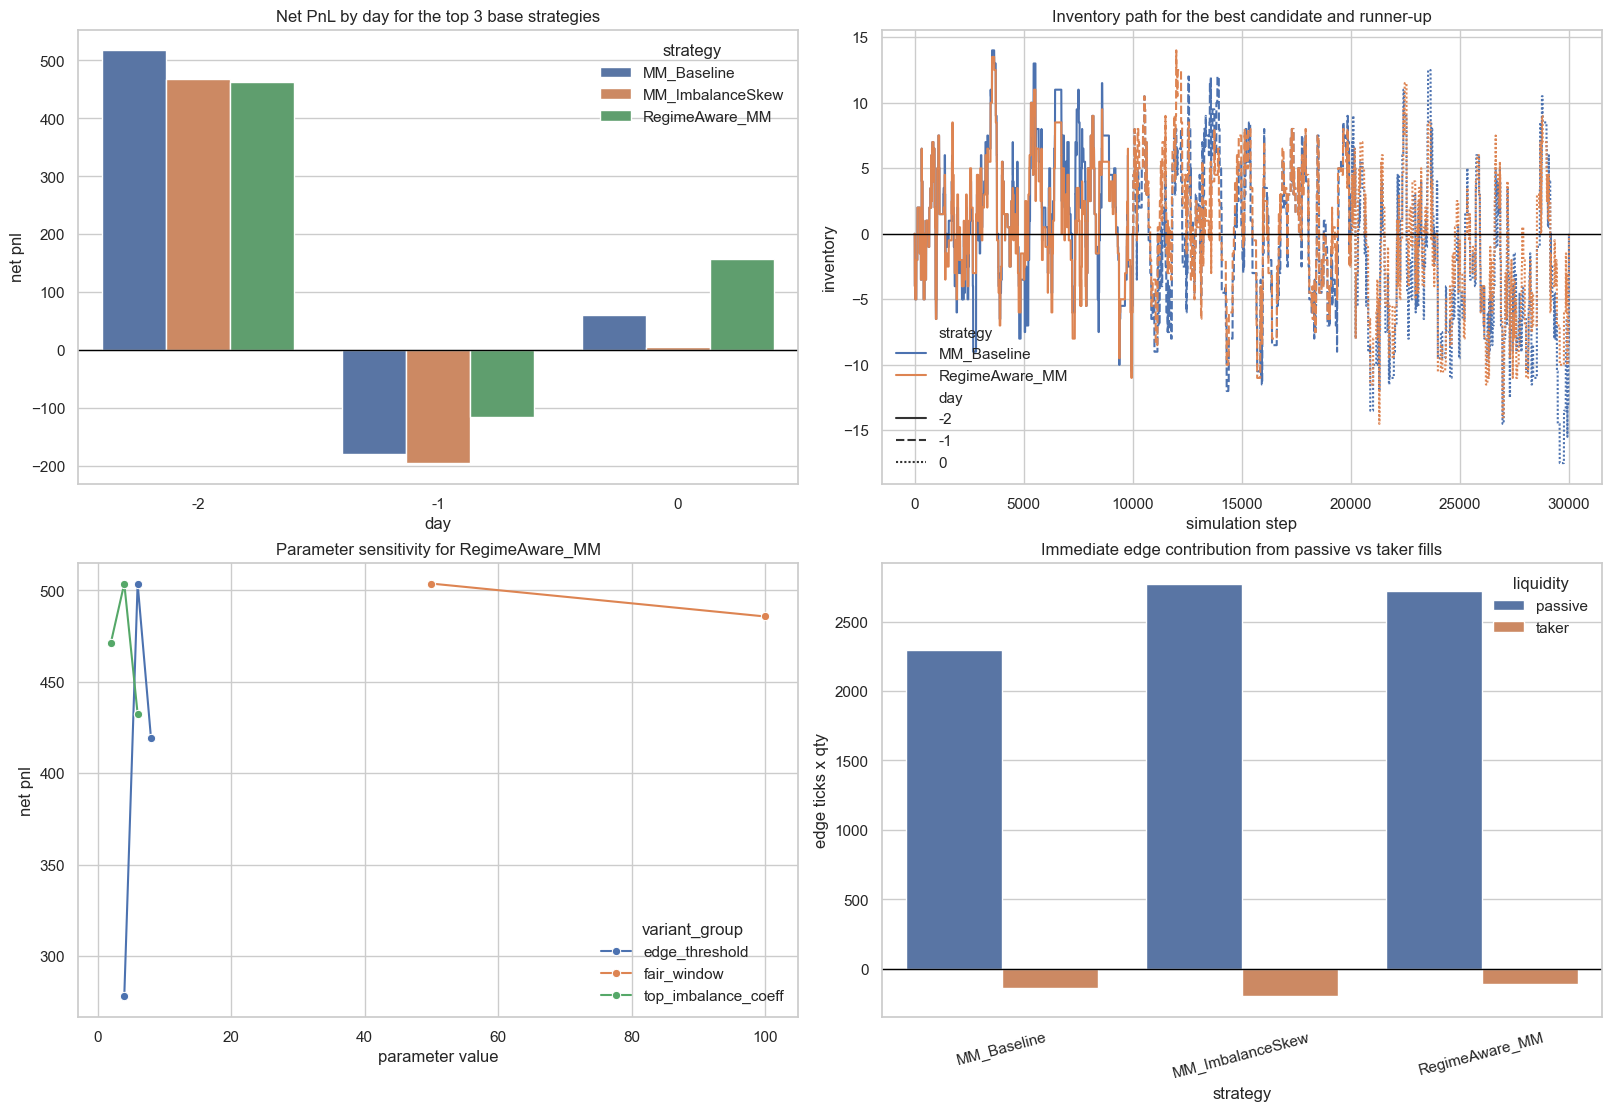

In [25]:
sensitivity_configs = build_sensitivity_configs(strategy_summary, strategy_configs, ash_strategy)
sensitivity_summary, sensitivity_daily, sensitivity_trades, sensitivity_inventory = run_strategy_grid(
    ash_strategy,
    trades,
    sensitivity_configs,
    execution_cfg,
)

sensitivity_summary = sensitivity_summary.sort_values(['parent_strategy', 'credibility_rank']).reset_index(drop=True)
robustness_by_day = strategy_daily.pivot(index='strategy', columns='day', values='net_pnl').reset_index()

print('Top sensitivity variants for the top 2 base strategies')
display(
    sensitivity_summary.groupby('parent_strategy', group_keys=False)
    .head(8)[['parent_strategy', 'strategy', 'variant_group', 'variant_value', 'net_pnl', 'daily_hit_rate', 'max_drawdown']]
)
print('Per-day robustness pivot')
display(robustness_by_day)

plot_strategy_diagnostics(strategy_summary, strategy_daily, inventory_paths, strategy_trades, sensitivity_summary)

## 17. Failure cases and caveats

The failure-case table keeps the skeptical lens from the EDA. Strategies that depend too heavily on taker fills, slow mean reversion, or optimistic passive capture should be called out explicitly even if they produce isolated good moments.

In [26]:
strategy_risk_map = {
    'RegimeAware_MM': 'Still relies on passive capture after one-sided regimes; if live queue priority is worse than the 50% haircut, the edge can compress quickly.',
    'MM_Baseline': 'No explicit regime filter, so it can keep quoting through temporary one-sided stress and absorb more shallow adverse inventory than the regime-aware variant.',
    'MM_ImbalanceSkew': 'Skew helps, but it still leans on displayed imbalance that can fade before passive fills arrive.',
    'AnchorReversion': 'Directional inventory can accumulate before mean reversion arrives; the day-end flattening cost dominates when the snap-back is slow.',
    'MM_ImbalanceSkew_TakerOverlay': 'The taker overlay pays too much for very short-horizon moves; the edge disappears once visible slippage and the taker penalty are applied.',
}

taker_turnover_share = (
    strategy_daily.assign(taker_turnover_share=lambda df: np.where(df['turnover'] > 0, df['taker_turnover'] / df['turnover'], 0.0))
    [['strategy', 'day', 'taker_turnover_share']]
)
worst_day = strategy_daily.loc[strategy_daily.groupby('strategy')['net_pnl'].idxmin(), ['strategy', 'day', 'net_pnl', 'max_drawdown']]
failure_cases = worst_day.merge(
    taker_turnover_share.loc[taker_turnover_share.groupby('strategy')['taker_turnover_share'].idxmax()],
    on=['strategy', 'day'],
    how='left',
)
failure_cases['main_caveat'] = failure_cases['strategy'].map(strategy_risk_map)

trade_log_pnl = (
    strategy_trades.assign(
        net_cash_flow=lambda df: np.where(df['side'] == 'buy', -df['fill_price_net'] * df['qty'], df['fill_price_net'] * df['qty'])
    )
    .groupby('strategy')['net_cash_flow']
    .sum()
    .sort_index()
)
summary_pnl = strategy_summary.set_index('strategy')['net_pnl'].sort_index()

assert (strategy_trades.loc[~strategy_trades['forced_flat'], 'timestamp'] > strategy_trades.loc[~strategy_trades['forced_flat'], 'signal_timestamp']).all()
assert (strategy_trades.query("liquidity == 'taker'")['qty'] <= strategy_trades.query("liquidity == 'taker'")['visible_depth_available'] + 1e-9).all()
assert strategy_trades.query("liquidity == 'passive'")['book_state_at_fill'].ne('empty').all()
assert inventory_paths['inventory'].abs().max() <= execution_cfg['inventory_limit'] + 1e-9
assert inventory_paths.groupby(['strategy', 'day'])['inventory'].last().abs().max() <= 1e-9
assert np.allclose(summary_pnl.values, strategy_daily.groupby('strategy')['net_pnl'].sum().sort_index().values)
assert np.allclose(summary_pnl.values, trade_log_pnl.reindex(summary_pnl.index).values)

sanity_checks = pd.DataFrame(
    [
        {'check': 'No lookahead fills', 'status': 'pass'},
        {'check': 'Taker fills stay within visible 3-level depth', 'status': 'pass'},
        {'check': 'Passive fills never occur in empty books', 'status': 'pass'},
        {'check': 'Inventory never breaches +/-20', 'status': 'pass'},
        {'check': 'Each strategy ends each day flat', 'status': 'pass'},
        {'check': 'Summary PnL matches daily and trade-log totals', 'status': 'pass'},
    ]
)

print('Failure cases')
display(failure_cases.sort_values('net_pnl'))
print('Sanity checks')
display(sanity_checks)

Failure cases


,strategy,day,net_pnl,max_drawdown,taker_turnover_share,main_caveat
3,MM_ImbalanceSkew_TakerOverlay,-1,"-7,327.250","12,891.500",0.530,The taker overlay pays too much for very short...
0,AnchorReversion,0,"-1,836.250","4,233.750",NaN,Directional inventory can accumulate before me...
2,MM_ImbalanceSkew,-1,-194.500,430.000,NaN,"Skew helps, but it still leans on displayed im..."
1,MM_Baseline,-1,-178.250,406.000,NaN,"No explicit regime filter, so it can keep quot..."
4,RegimeAware_MM,-1,-115.750,393.750,NaN,Still relies on passive capture after one-side...


Sanity checks


,check,status
0,No lookahead fills,pass
1,Taker fills stay within visible 3-level depth,pass
2,Passive fills never occur in empty books,pass
3,Inventory never breaches +/-20,pass
4,Each strategy ends each day flat,pass
5,Summary PnL matches daily and trade-log totals,pass


## 18. Final recommendation

The final recommendation below answers the practical handoff question: which base strategy still looks believable after conservative execution modelling, which one is next best, what risks matter most, and what exact features and follow-up experiments should be ported into the real competition bot.

In [27]:
from IPython.display import Markdown

best_candidate = strategy_summary.nsmallest(2, 'credibility_rank').iloc[0]['strategy']
runner_up = strategy_summary.nsmallest(2, 'credibility_rank').iloc[1]['strategy']
best_sensitivity = sensitivity_summary.sort_values(['net_pnl', 'max_drawdown'], ascending=[False, True]).iloc[0]

ported_feature_table = pd.DataFrame(
    [
        {'feature': 'clean_mid', 'reason': 'Two-sided-only touch midpoint with carry-forward cleaning avoids one-sided and empty-book distortions.'},
        {'feature': 'rolling_fair_50', 'reason': 'Primary short-horizon reservation price for quoting.'},
        {'feature': 'rolling_anchor_200', 'reason': 'Slower anchor for deciding when a move is stretched enough to fade.'},
        {'feature': 'imbalance_top', 'reason': 'Strongest near-touch directional signal in the EDA.'},
        {'feature': 'imbalance_3lvl', 'reason': 'Adds depth context beyond the best level and improves skew stability.'},
        {'feature': 'lagged_return_1', 'reason': 'Captures the strongest snap-back effect directly.'},
        {'feature': 'momentum_5', 'reason': 'Short reversal context for distinguishing a blip from a small run.'},
        {'feature': 'distance_from_anchor', 'reason': 'Explicit stretch-versus-anchor signal for fade sizing and taker gating.'},
        {'feature': 'book_state flags', 'reason': 'One-sided and empty books behave differently and need separate policy branches.'},
        {'feature': 'interaction_reversion_top', 'reason': 'Best compact interaction for identifying imbalance x reversal alignment.'},
    ]
)

next_experiments = [
    'Retest the regime-aware and baseline market makers with edge_threshold = 8, since the sensitivity pass materially improved net PnL at that setting.',
    'Stress the passive model harder by raising the queue haircut above 50% and disabling move-through fills to see whether the ranking survives a harsher live-fill assumption.',
    'Try a stricter taker overlay that also requires large anchor distance, because the current taker-heavy overlay loses badly once visible slippage and the 0.5-tick penalty are included.',
]

recommendation_md = f"""
**Best candidate strategy:** `{best_candidate}`.
It was the best base strategy under the strict execution model, stayed positive on all three days, and handled one-sided-book episodes more cleanly than the plain market makers.

**Runner-up:** `{runner_up}`.
It is simpler and still credible, but it gives back some robustness because it keeps quoting through regimes that the winner treats more defensively.

**Most important risk with each**
- `{best_candidate}`: {strategy_risk_map[best_candidate]}
- `{runner_up}`: {strategy_risk_map[runner_up]}

**Exact features to port into the competition bot**
"""
for feature in ported_feature_table['feature']:
    recommendation_md += f"- `{feature}`\n"
recommendation_md += f"""

**Best sensitivity result to try next:** `{best_sensitivity['strategy']}` with net PnL {best_sensitivity['net_pnl']:.2f}.
This is not the official base-strategy winner, but it is the most promising immediate parameter follow-up from the compact sensitivity pass.

**Next 3 experiments**
"""
for experiment in next_experiments:
    recommendation_md += f"- {experiment}\n"

print('Features to port')
display(ported_feature_table)
display(Markdown(recommendation_md))

Features to port


,feature,reason
0,clean_mid,Two-sided-only touch midpoint with carry-forwa...
1,rolling_fair_50,Primary short-horizon reservation price for qu...
2,rolling_anchor_200,Slower anchor for deciding when a move is stre...
3,imbalance_top,Strongest near-touch directional signal in the...
4,imbalance_3lvl,Adds depth context beyond the best level and i...
5,lagged_return_1,Captures the strongest snap-back effect directly.
6,momentum_5,Short reversal context for distinguishing a bl...
7,distance_from_anchor,Explicit stretch-versus-anchor signal for fade...
8,book_state flags,One-sided and empty books behave differently a...
9,interaction_reversion_top,Best compact interaction for identifying imbal...



**Best candidate strategy:** `RegimeAware_MM`.
It was the best base strategy under the strict execution model, stayed positive on all three days, and handled one-sided-book episodes more cleanly than the plain market makers.

**Runner-up:** `MM_Baseline`.
It is simpler and still credible, but it gives back some robustness because it keeps quoting through regimes that the winner treats more defensively.

**Most important risk with each**
- `RegimeAware_MM`: Still relies on passive capture after one-sided regimes; if live queue priority is worse than the 50% haircut, the edge can compress quickly.
- `MM_Baseline`: No explicit regime filter, so it can keep quoting through temporary one-sided stress and absorb more shallow adverse inventory than the regime-aware variant.

**Exact features to port into the competition bot**
- `clean_mid`
- `rolling_fair_50`
- `rolling_anchor_200`
- `imbalance_top`
- `imbalance_3lvl`
- `lagged_return_1`
- `momentum_5`
- `distance_from_anchor`
- `book_state flags`
- `interaction_reversion_top`


**Best sensitivity result to try next:** `MM_Baseline | edge=8` with net PnL 573.00.
This is not the official base-strategy winner, but it is the most promising immediate parameter follow-up from the compact sensitivity pass.

**Next 3 experiments**
- Retest the regime-aware and baseline market makers with edge_threshold = 8, since the sensitivity pass materially improved net PnL at that setting.
- Stress the passive model harder by raising the queue haircut above 50% and disabling move-through fills to see whether the ranking survives a harsher live-fill assumption.
- Try a stricter taker overlay that also requires large anchor distance, because the current taker-heavy overlay loses badly once visible slippage and the 0.5-tick penalty are included.
